<a href="https://colab.research.google.com/github/trang1981/ELAPS/blob/main/Notebooks/VIB_ELAPS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TRAINING LIGHTGBM

In [ ]:
# ==========================================================
# LIGHTGBM WITH 5 SAMPLING STRATEGIES
# TARGET: COUNT_CREDITCARD
# ==========================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import recall_score, f1_score, roc_auc_score, accuracy_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE, BorderlineSMOTE, ADASYN

from lightgbm import LGBMClassifier

# =========================
# LOAD DATA
# =========================
df = pd.read_csv(
    "final_dataset_no_auto_job.csv",
    low_memory=False
)

df.columns = df.columns.str.strip()

# =========================
# TARGET AND ID
# =========================
target_col = "COUNT_CREDITCARD"
id_col = "CUSTOMER_NUMBER"

# X, y
y = df[target_col].astype(int)

X = df.drop(columns=[target_col])

if id_col in X.columns:
    X = X.drop(columns=[id_col])

# =========================
# FIX MIXED DATA TYPES
# =========================
for col in X.columns:
    if X[col].dtype == "object":
        X[col] = X[col].astype(str)

# =========================
# NUMERIC / CATEGORICAL COLUMNS
# =========================
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numeric columns:", len(num_cols))
print("Categorical columns:", len(cat_cols))

# =========================
# PREPROCESSOR
# =========================
preprocessor = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), num_cols),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols)
    ],
    remainder="drop"
)

# =========================
# TRAIN / TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================
# SAMPLING METHODS
# =========================
sampling_methods = {
    "No Sampling": None,
    "ROS": RandomOverSampler(random_state=42),
    "SMOTE": SMOTE(random_state=42),
    "Borderline-SMOTE": BorderlineSMOTE(random_state=42),
    "ADASYN": ADASYN(random_state=42)
}

# =========================
# LIGHTGBM MODEL
# =========================
lgbm_model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

# =========================
# CROSS VALIDATION
# =========================
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "recall": "recall",
    "f1": "f1",
    "auc": "roc_auc",
    "accuracy": "accuracy"
}

results = []

# =========================
# TRAINING AND EVALUATION
# =========================
for sampling_name, sampler in sampling_methods.items():

    steps = [("preprocess", preprocessor)]

    if sampler is not None:
        steps.append(("sampler", sampler))

    steps.append(("model", lgbm_model))

    pipeline = Pipeline(steps=steps)

    cv_scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        error_score="raise"
    )

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    results.append({
        "Sampling": sampling_name,
        "Model": "LightGBM",
        "Recall": round(cv_scores["test_recall"].mean(), 4),
        "F1-score": round(cv_scores["test_f1"].mean(), 4),
        "AUC": round(cv_scores["test_auc"].mean(), 4),
        "Accuracy": round(cv_scores["test_accuracy"].mean(), 4),
        "Std (CV AUC)": round(cv_scores["test_auc"].std(), 4),
        "Test Recall": round(recall_score(y_test, y_pred), 4),
        "Test F1-score": round(f1_score(y_test, y_pred), 4),
        "Test AUC": round(roc_auc_score(y_test, y_prob), 4),
        "Test Accuracy": round(accuracy_score(y_test, y_pred), 4)
    })

# =========================
# RESULT TABLE
# =========================
result_df = pd.DataFrame(results)

print(result_df)

result_df.to_csv("lightgbm_5_sampling_results.csv", index=False)

print("\nSaved: lightgbm_5_sampling_results.csv")


Numeric columns: 14
Categorical columns: 6


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

           Sampling     Model  Recall  F1-score     AUC  Accuracy  \
0       No Sampling  LightGBM  0.6600    0.6806  0.9507    0.9042   
1               ROS  LightGBM  0.9267    0.6856  0.9503    0.8685   
2             SMOTE  LightGBM  0.8540    0.6932  0.9462    0.8831   
3  Borderline-SMOTE  LightGBM  0.8696    0.6847  0.9379    0.8761   
4            ADASYN  LightGBM  0.8644    0.6849  0.9433    0.8770   

   Std (CV AUC)  Test Recall  Test F1-score  Test AUC  Test Accuracy  
0        0.0014       0.6584         0.6779    0.9510         0.9032  
1        0.0014       0.9277         0.6891    0.9507         0.8705  
2        0.0011       0.8600         0.6989    0.9468         0.8854  
3        0.0008       0.8740         0.6858    0.9388         0.8762  
4        0.0013       0.8704         0.6898    0.9438         0.8789  

Saved: lightgbm_5_sampling_results.csv


*CHẠY* HUẤN LUYỆN MÔ HÌNH


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import recall_score, f1_score, roc_auc_score, accuracy_score
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import RandomOverSampler, SMOTE, BorderlineSMOTE, ADASYN

# =========================
# LOAD DATA
# =========================
df = pd.read_csv("final_dataset_no_auto_job.csv")
df.columns = df.columns.str.strip()

# =========================
# TARGET
# =========================
y = df["COUNT_CREDITCARD"]
X = df.drop(["CUSTOMER_NUMBER", "COUNT_CREDITCARD"], axis=1).copy()

# =========================
# ENCODE CATEGORICAL
# =========================
for col in X.select_dtypes(include="object").columns:
    X[col] = X[col].astype("category").cat.codes

# =========================
# TRAIN TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# =========================
# MODELS
# =========================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "GBDT": GradientBoostingClassifier(random_state=42),
    "Extra Trees": ExtraTreesClassifier(n_estimators=200, random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    )
}

# =========================
# SAMPLING METHODS
# None = No sampling
# =========================
samplers = {
    "No sampling": None,
    "RandomOverSampling": RandomOverSampler(random_state=42),
    "SMOTE": SMOTE(random_state=42),
    "Borderline-SMOTE": BorderlineSMOTE(random_state=42),
    "ADASYN": ADASYN(random_state=42)
}

# =========================
# CROSS VALIDATION ON TRAIN
# =========================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []

for sampler_name, sampler in samplers.items():
    for model_name, model in models.items():

        recall_scores = []
        f1_scores = []
        auc_scores = []
        acc_scores = []

        for train_index, val_index in skf.split(X_train, y_train):
            X_tr = X_train.iloc[train_index].copy()
            X_val = X_train.iloc[val_index].copy()
            y_tr = y_train.iloc[train_index].copy()
            y_val = y_train.iloc[val_index].copy()

            # Impute only on train fold
            imputer = SimpleImputer(strategy="median")
            X_tr = pd.DataFrame(
                imputer.fit_transform(X_tr),
                columns=X_tr.columns,
                index=X_tr.index
            )
            X_val = pd.DataFrame(
                imputer.transform(X_val),
                columns=X_val.columns,
                index=X_val.index
            )

            # Resample only on train fold
            if sampler is None:
                X_tr_res, y_tr_res = X_tr, y_tr
            else:
                X_tr_res, y_tr_res = sampler.fit_resample(X_tr, y_tr)

            # Fit
            model.fit(X_tr_res, y_tr_res)

            # Validate
            y_pred = model.predict(X_val)
            y_prob = model.predict_proba(X_val)[:, 1]

            recall_scores.append(recall_score(y_val, y_pred, zero_division=0))
            f1_scores.append(f1_score(y_val, y_pred, zero_division=0))
            auc_scores.append(roc_auc_score(y_val, y_prob))
            acc_scores.append(accuracy_score(y_val, y_pred))

        cv_results.append({
            "Sampling": sampler_name,
            "Model": model_name,
            "Recall": np.mean(recall_scores),
            "F1-score": np.mean(f1_scores),
            "AUC": np.mean(auc_scores),
            "Accuracy": np.mean(acc_scores),
            "Std (CV AUC)": np.std(auc_scores)
        })

cv_result_df = pd.DataFrame(cv_results)
cv_result_df = cv_result_df.sort_values(["Sampling", "AUC"], ascending=[True, False])

print("===== CV RESULTS =====")
print(cv_result_df)

# =========================
# TEST EVALUATION
# =========================
test_results = []

for sampler_name, sampler in samplers.items():
    for model_name, model in models.items():

        # Impute on full train, transform test
        imputer = SimpleImputer(strategy="median")
        X_train_imp = pd.DataFrame(
            imputer.fit_transform(X_train),
            columns=X_train.columns,
            index=X_train.index
        )
        X_test_imp = pd.DataFrame(
            imputer.transform(X_test),
            columns=X_test.columns,
            index=X_test.index
        )

        # Resample only training set
        if sampler is None:
            X_train_res, y_train_res = X_train_imp, y_train
        else:
            X_train_res, y_train_res = sampler.fit_resample(X_train_imp, y_train)

        # Fit on full train
        model.fit(X_train_res, y_train_res)

        # Predict on test
        y_test_pred = model.predict(X_test_imp)
        y_test_prob = model.predict_proba(X_test_imp)[:, 1]

        test_results.append({
            "Sampling": sampler_name,
            "Model": model_name,
            "Test Recall": recall_score(y_test, y_test_pred, zero_division=0),
            "Test F1-score": f1_score(y_test, y_test_pred, zero_division=0),
            "Test AUC": roc_auc_score(y_test, y_test_prob),
            "Test Accuracy": accuracy_score(y_test, y_test_pred)
        })

test_result_df = pd.DataFrame(test_results)
test_result_df = test_result_df.sort_values(["Sampling", "Test AUC"], ascending=[True, False])

print("===== TEST RESULTS =====")
print(test_result_df)

# =========================
# SAVE
# =========================
final_result_df = cv_result_df.merge(
    test_result_df,
    on=["Sampling", "Model"],
    how="left"
)

final_result_df.to_csv("model_comparison_final_results.csv", index=False)

print("Saved: model_comparison_final_results.csv")

/tmp/ipykernel_1551/1562968304.py:18: DtypeWarning: Columns (2,3,4,9,10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("final_dataset_no_auto_job.csv")


===== CV RESULTS =====
              Sampling                Model    Recall  F1-score       AUC  \
29              ADASYN              XGBoost  0.870332  0.684749  0.944140   
26              ADASYN                 GBDT  0.899245  0.676139  0.942167   
28              ADASYN             AdaBoost  0.910532  0.667006  0.936405   
25              ADASYN        Random Forest  0.824044  0.674399  0.934059   
27              ADASYN          Extra Trees  0.806544  0.666877  0.925822   
24              ADASYN  Logistic Regression  0.599213  0.396228  0.814837   
20    Borderline-SMOTE                 GBDT  0.910659  0.677967  0.940233   
23    Borderline-SMOTE              XGBoost  0.875024  0.687425  0.939323   
22    Borderline-SMOTE             AdaBoost  0.921311  0.667788  0.935492   
19    Borderline-SMOTE        Random Forest  0.797412  0.668307  0.929305   
21    Borderline-SMOTE          Extra Trees  0.778390  0.660702  0.920966   
18    Borderline-SMOTE  Logistic Regression  0.568533

THÊM CHỈ SỐ KS

In [ ]:
# ==========================================================
# CALCULATE KS ONLY FOR ALL SAMPLING × MODEL SCENARIOS
# Target: COUNT_CREDITCARD
# ==========================================================

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_curve

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from imblearn.over_sampling import (
    RandomOverSampler,
    SMOTE,
    BorderlineSMOTE,
    ADASYN
)

# =========================
# 1. LOAD DATA
# =========================

df = pd.read_csv("final_dataset_no_auto_job.csv", low_memory=False)
df.columns = df.columns.str.strip()

target_col = "COUNT_CREDITCARD"
id_col = "CUSTOMER_NUMBER"

# Binary target: 1 if customer owns credit card, 0 otherwise
y = (df[target_col] > 0).astype(int)

X = df.drop(columns=[target_col])

if id_col in X.columns:
    X = X.drop(columns=[id_col])

# =========================
# 2. ENCODE CATEGORICAL VARIABLES
# =========================

for col in X.select_dtypes(include=["object", "category"]).columns:
    X[col] = X[col].astype("category").cat.codes

# =========================
# 3. TRAIN-TEST SPLIT
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# =========================
# 4. MEDIAN IMPUTATION
# =========================

imputer = SimpleImputer(strategy="median")

X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)

# =========================
# 5. KS FUNCTION
# =========================

def calculate_ks(y_true, y_score):
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    ks = np.max(tpr - fpr)
    return ks

# =========================
# 6. SAMPLING METHODS
# =========================

samplers = {
    "ADASYN": ADASYN(random_state=42),
    "Borderline-SMOTE": BorderlineSMOTE(random_state=42),
    "No sampling": None,
    "Random Oversampling": RandomOverSampler(random_state=42),
    "SMOTE": SMOTE(random_state=42)
}

# =========================
# 7. MODELS
# =========================

models = {
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ),

    "GBDT": GradientBoostingClassifier(
        random_state=42
    ),

    "AdaBoost": AdaBoostClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    ),

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    )
}

# =========================
# 8. REQUIRED SCENARIOS
# =========================

scenarios = [
    ("ADASYN", "XGBoost"),
    ("ADASYN", "GBDT"),
    ("ADASYN", "AdaBoost"),
    ("ADASYN", "Random Forest"),
    ("ADASYN", "Extra Trees"),
    ("ADASYN", "LightGBM"),
    ("ADASYN", "Logistic Regression"),

    ("Borderline-SMOTE", "GBDT"),
    ("Borderline-SMOTE", "XGBoost"),
    ("Borderline-SMOTE", "AdaBoost"),
    ("Borderline-SMOTE", "Random Forest"),
    ("Borderline-SMOTE", "Extra Trees"),
    ("Borderline-SMOTE", "LightGBM"),
    ("Borderline-SMOTE", "Logistic Regression"),

    ("No sampling", "XGBoost"),
    ("No sampling", "GBDT"),
    ("No sampling", "Random Forest"),
    ("No sampling", "AdaBoost"),
    ("No sampling", "Extra Trees"),
    ("No sampling", "LightGBM"),
    ("No sampling", "Logistic Regression"),

    ("Random Oversampling", "XGBoost"),
    ("Random Oversampling", "GBDT"),
    ("Random Oversampling", "Random Forest"),
    ("Random Oversampling", "AdaBoost"),
    ("Random Oversampling", "Extra Trees"),
    ("Random Oversampling", "LightGBM"),
    ("Random Oversampling", "Logistic Regression"),

    ("SMOTE", "XGBoost"),
    ("SMOTE", "GBDT"),
    ("SMOTE", "Random Forest"),
    ("SMOTE", "AdaBoost"),
    ("SMOTE", "Extra Trees"),
    ("SMOTE", "LightGBM"),
    ("SMOTE", "Logistic Regression")
]

# =========================
# 9. RUN KS ONLY
# =========================

ks_results = []

for sampling_name, model_name in scenarios:

    print(f"Running: {sampling_name} - {model_name}")

    sampler = samplers[sampling_name]
    model = models[model_name]

    if sampler is None:
        X_resampled = X_train_imp
        y_resampled = y_train
    else:
        X_resampled, y_resampled = sampler.fit_resample(
            X_train_imp,
            y_train
        )

    model.fit(X_resampled, y_resampled)

    y_prob = model.predict_proba(X_test_imp)[:, 1]

    ks = calculate_ks(y_test, y_prob)

    ks_results.append({
        "Sampling": sampling_name,
        "Model": model_name,
        "KS": round(ks, 4)
    })

# =========================
# 10. DISPLAY KS RESULTS ONLY
# =========================

ks_df = pd.DataFrame(ks_results)

print("\n===== KS STATISTIC RESULTS =====")
print(ks_df.to_string(index=False))

# Save result
ks_df.to_excel("ks_results_only.xlsx", index=False)

print("\nSaved: ks_results_only.xlsx")

Running: ADASYN - XGBoost
Running: ADASYN - GBDT
Running: ADASYN - AdaBoost
Running: ADASYN - Random Forest
Running: ADASYN - Extra Trees
Running: ADASYN - LightGBM
Running: ADASYN - Logistic Regression
Running: Borderline-SMOTE - GBDT
Running: Borderline-SMOTE - XGBoost
Running: Borderline-SMOTE - AdaBoost
Running: Borderline-SMOTE - Random Forest
Running: Borderline-SMOTE - Extra Trees
Running: Borderline-SMOTE - LightGBM
Running: Borderline-SMOTE - Logistic Regression
Running: No sampling - XGBoost
Running: No sampling - GBDT
Running: No sampling - Random Forest
Running: No sampling - AdaBoost
Running: No sampling - Extra Trees
Running: No sampling - LightGBM
Running: No sampling - Logistic Regression
Running: Random Oversampling - XGBoost
Running: Random Oversampling - GBDT
Running: Random Oversampling - Random Forest
Running: Random Oversampling - AdaBoost
Running: Random Oversampling - Extra Trees
Running: Random Oversampling - LightGBM
Running: Random Oversampling - Logistic Reg

CHẠY DELONGTEST

In [ ]:
# ==========================================================
# DELONG TEST FOR TOP 3 MODELS
# 1. XGBoost + RandomOverSampling
# 2. LightGBM + RandomOverSampling
# 3. LightGBM + SMOTE
# TARGET: COUNT_CREDITCARD
# ==========================================================

import pandas as pd
import numpy as np

from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.impute import SimpleImputer

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from imblearn.over_sampling import RandomOverSampler, SMOTE

# =========================
# LOAD DATA
# =========================
df = pd.read_csv("final_dataset_no_auto_job.csv", low_memory=False)
df.columns = df.columns.str.strip()

target_col = "COUNT_CREDITCARD"
id_col = "CUSTOMER_NUMBER"

y = df[target_col].astype(int)
X = df.drop(columns=[target_col])

if id_col in X.columns:
    X = X.drop(columns=[id_col])

# Encode categorical columns
for col in X.select_dtypes(include="object").columns:
    X[col] = X[col].astype(str).astype("category").cat.codes

# =========================
# TRAIN TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# =========================
# IMPUTATION
# =========================
imputer = SimpleImputer(strategy="median")

X_train_imp = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_imp = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

# =========================
# MODELS
# =========================
models = {
    "XGBoost + ROS": {
        "model": XGBClassifier(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            random_state=42
        ),
        "sampler": RandomOverSampler(random_state=42)
    },

    "LightGBM + ROS": {
        "model": LGBMClassifier(
            n_estimators=500,
            learning_rate=0.05,
            num_leaves=31,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1,
            verbosity=-1
        ),
        "sampler": RandomOverSampler(random_state=42)
    },

    "LightGBM + SMOTE": {
        "model": LGBMClassifier(
            n_estimators=500,
            learning_rate=0.05,
            num_leaves=31,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1,
            verbosity=-1
        ),
        "sampler": SMOTE(random_state=42)
    }
}

# =========================
# TRAIN AND SAVE PROBABILITIES
# =========================
pred_probs = {}
auc_scores = {}

for name, cfg in models.items():

    print(f"Training {name}...")

    sampler = cfg["sampler"]
    model = cfg["model"]

    X_res, y_res = sampler.fit_resample(X_train_imp, y_train)

    model.fit(X_res, y_res)

    y_prob = model.predict_proba(X_test_imp)[:, 1]

    pred_probs[name] = y_prob
    auc_scores[name] = roc_auc_score(y_test, y_prob)

print("\n===== TEST AUC =====")
for name, auc in auc_scores.items():
    print(f"{name}: {auc:.4f}")

# ==========================================================
# DELONG TEST FUNCTIONS
# ==========================================================

def compute_midrank(x):
    J = np.argsort(x)
    Z = x[J]
    N = len(x)

    T = np.zeros(N, dtype=float)
    i = 0

    while i < N:
        j = i
        while j < N and Z[j] == Z[i]:
            j += 1

        T[i:j] = 0.5 * (i + j - 1) + 1
        i = j

    T2 = np.empty(N, dtype=float)
    T2[J] = T

    return T2


def fast_delong(predictions_sorted_transposed, label_1_count):

    m = label_1_count
    n = predictions_sorted_transposed.shape[1] - m

    positive_examples = predictions_sorted_transposed[:, :m]
    negative_examples = predictions_sorted_transposed[:, m:]

    k = predictions_sorted_transposed.shape[0]

    tx = np.empty((k, m))
    ty = np.empty((k, n))
    tz = np.empty((k, m + n))

    for r in range(k):
        tx[r, :] = compute_midrank(positive_examples[r, :])
        ty[r, :] = compute_midrank(negative_examples[r, :])
        tz[r, :] = compute_midrank(predictions_sorted_transposed[r, :])

    aucs = tz[:, :m].sum(axis=1) / m / n - (m + 1.0) / (2.0 * n)

    v01 = (tz[:, :m] - tx) / n
    v10 = 1.0 - (tz[:, m:] - ty) / m

    sx = np.cov(v01)
    sy = np.cov(v10)

    delongcov = sx / m + sy / n

    return aucs, delongcov


def calc_pvalue(aucs, sigma):

    l = np.array([[1, -1]])

    variance = np.dot(np.dot(l, sigma), l.T)

    if variance <= 0:
        return 1.0

    z = np.abs(np.diff(aucs)) / np.sqrt(variance)

    pvalue = 2 * (1 - stats.norm.cdf(z))

    return float(pvalue)


def delong_roc_test(y_true, pred1, pred2):

    y_true = np.asarray(y_true)
    pred1 = np.asarray(pred1)
    pred2 = np.asarray(pred2)

    order = np.argsort(-y_true)

    label_1_count = int(np.sum(y_true))

    predictions = np.vstack((pred1, pred2))
    predictions_sorted_transposed = predictions[:, order]

    aucs, delongcov = fast_delong(
        predictions_sorted_transposed,
        label_1_count
    )

    pvalue = calc_pvalue(aucs, delongcov)

    return aucs, pvalue

# =========================
# RUN DELONG TEST
# =========================
comparisons = [
    ("XGBoost + ROS", "LightGBM + ROS"),
    ("XGBoost + ROS", "LightGBM + SMOTE"),
    ("LightGBM + ROS", "LightGBM + SMOTE")
]

delong_results = []

for m1, m2 in comparisons:

    aucs, p_value = delong_roc_test(
        y_test.values,
        pred_probs[m1],
        pred_probs[m2]
    )

    delong_results.append({
        "Model 1": m1,
        "AUC Model 1": round(aucs[0], 4),
        "Model 2": m2,
        "AUC Model 2": round(aucs[1], 4),
        "Delta AUC": round(abs(aucs[0] - aucs[1]), 4),
        "p-value": round(p_value, 6),
        "Significant (p<0.05)": "Yes" if p_value < 0.05 else "No"
    })

delong_df = pd.DataFrame(delong_results)

print("\n===== DELONG TEST RESULTS =====")
print(delong_df)

delong_df.to_csv("delong_test_top3_models.csv", index=False)

print("\nSaved: delong_test_top3_models.csv")

Training XGBoost + ROS...
Training LightGBM + ROS...
Training LightGBM + SMOTE...

===== TEST AUC =====
XGBoost + ROS: 0.9508
LightGBM + ROS: 0.9503
LightGBM + SMOTE: 0.9465


/tmp/ipykernel_8207/2644697248.py:215: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(pvalue)



===== DELONG TEST RESULTS =====
          Model 1  AUC Model 1           Model 2  AUC Model 2  Delta AUC  \
0   XGBoost + ROS       0.9508    LightGBM + ROS       0.9503     0.0005   
1   XGBoost + ROS       0.9508  LightGBM + SMOTE       0.9465     0.0043   
2  LightGBM + ROS       0.9503  LightGBM + SMOTE       0.9465     0.0038   

    p-value Significant (p<0.05)  
0  0.025707                  Yes  
1  0.000000                  Yes  
2  0.000000                  Yes  

Saved: delong_test_top3_models.csv


Categorical columns: ['CLIENT_SEX', 'EB_REGISTER_CHANNEL', 'SMS', 'VERIFY_METHOD', 'TRANS_LV1_MODE', 'TRANS_LV2_MODE']
Numerical columns: ['AGE', 'LOGIN_PER_ACTIVE_DAY', 'INTEREST_RATE_RATIO', 'TRANS_AMOUNT_MAX', 'TRANS_AMOUNT_MEAN', 'TRANS_LV1_MODE_CODE', 'TRANS_LV2_MODE_CODE', 'COUNT_CA_ACCT', 'AVG_CA_BALANCE', 'COUNT_TD_ACCT', 'AVG_TD_BALANCE', 'COUNT_OF_LOAN', 'AVG_LOAN_AMOUNT', 'TOTAL_LOAN_AMOUNT']
Dataset shape: (127460, 22)
Target distribution:
COUNT_CREDITCARD
0    0.845332
1    0.154668
Name: proportion, dtype: float64
Fold 1 | Recall=0.9331 | F1=0.6895 | AUC=0.9524 | Accuracy=0.8700
Fold 2 | Recall=0.9280 | F1=0.6822 | AUC=0.9498 | Accuracy=0.8663
Fold 3 | Recall=0.9283 | F1=0.6827 | AUC=0.9505 | Accuracy=0.8665
Fold 4 | Recall=0.9236 | F1=0.6859 | AUC=0.9488 | Accuracy=0.8692
Fold 5 | Recall=0.9261 | F1=0.6898 | AUC=0.9523 | Accuracy=0.8712

===== CV RESULTS: XGBOOST + ROS =====
                                Model  CV Recall  CV F1-score    CV AUC  \
0  XGBoost + RandomOve

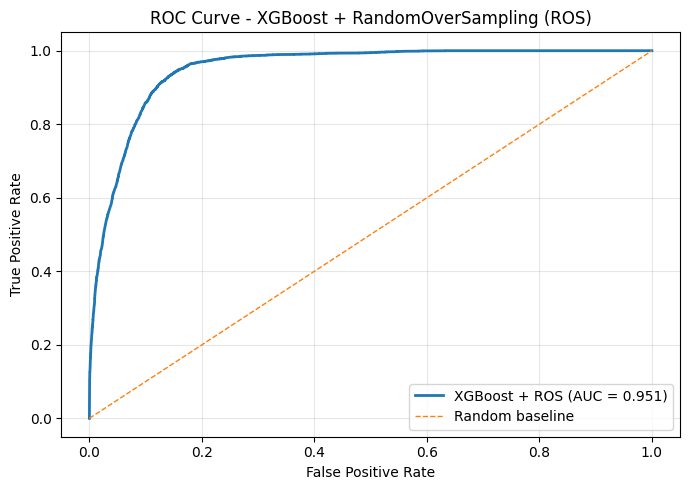


===== DECILE TABLE: XGBOOST + ROS =====
  Decile  Customers  Positives  Adoption_Rate  Avg_Pred_Prob      Lift
0     D1       2550       1993       0.781569       0.942235  5.052941
1     D2       2549       1226       0.480973       0.828497  3.109552
2     D3       2549        579       0.227148       0.544064  1.468540
3     D4       2549         93       0.036485       0.142864  0.235880
4     D5       2549         21       0.008239       0.047451  0.053263
5     D6       2549         18       0.007062       0.022893  0.045654
6     D7       2549         13       0.005100       0.011192  0.032972
7     D8       2549          0       0.000000       0.006057  0.000000
8     D9       2549          0       0.000000       0.002931  0.000000
9    D10       2550          0       0.000000       0.000690  0.000000


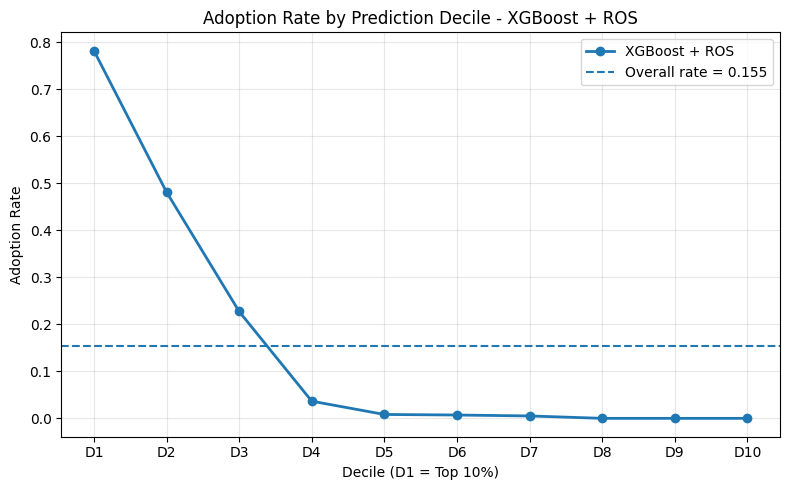

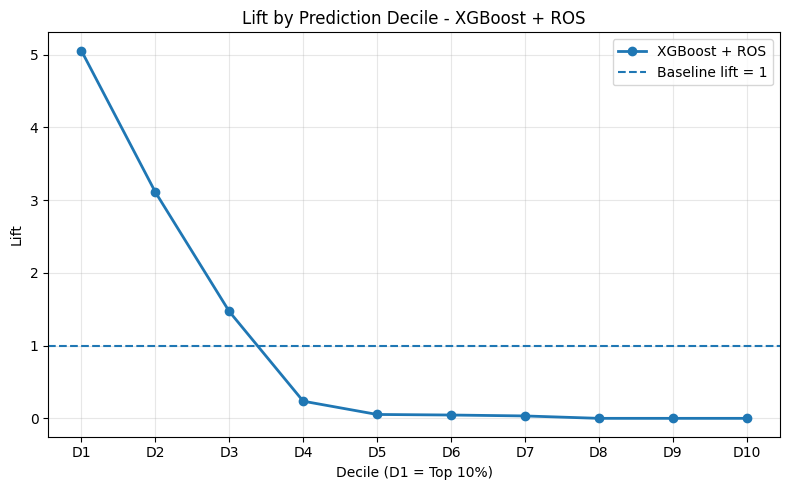


===== PRECISION@TOP-K: XGBOOST + ROS =====
                                Model    Top_K  Customers  Precision  \
0  XGBoost + RandomOverSampling (ROS)  Top 10%       2550   0.781569   
1  XGBoost + RandomOverSampling (ROS)  Top 20%       5099   0.631300   
2  XGBoost + RandomOverSampling (ROS)  Top 30%       7648   0.496600   

   Captured_Positives  Capture_Rate  
0                1993      0.505453  
1                3219      0.816383  
2                3798      0.963226  


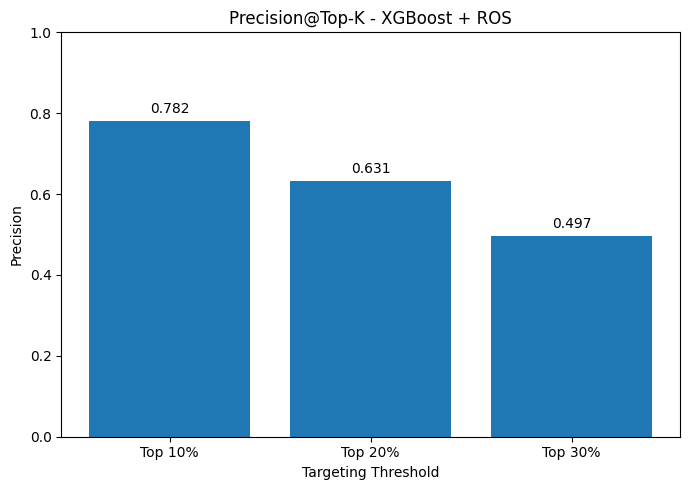

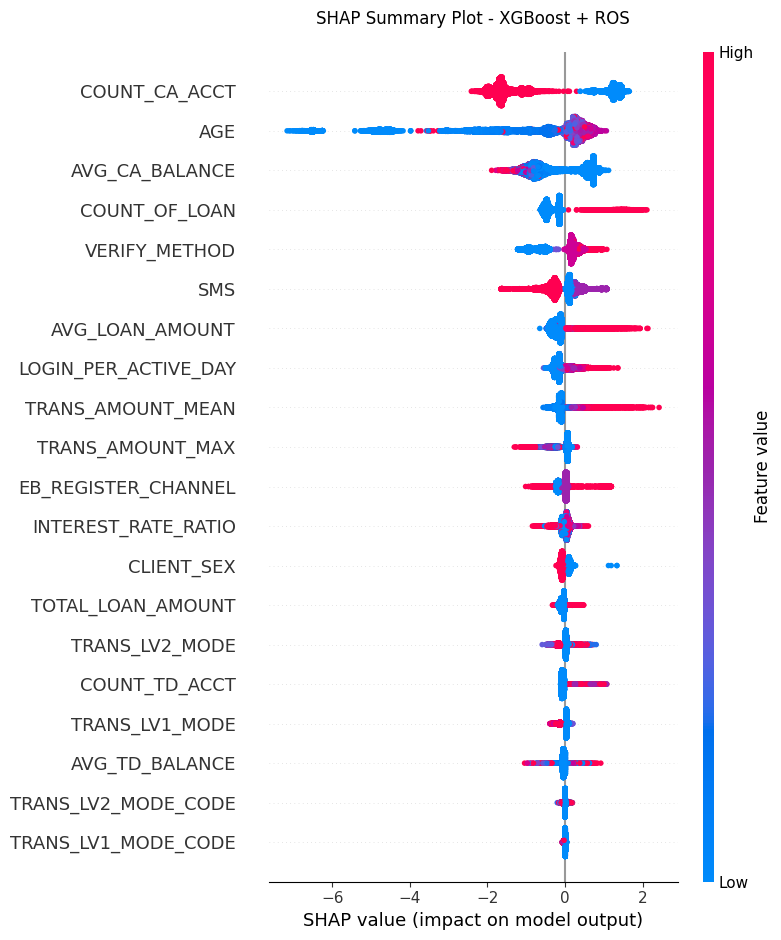

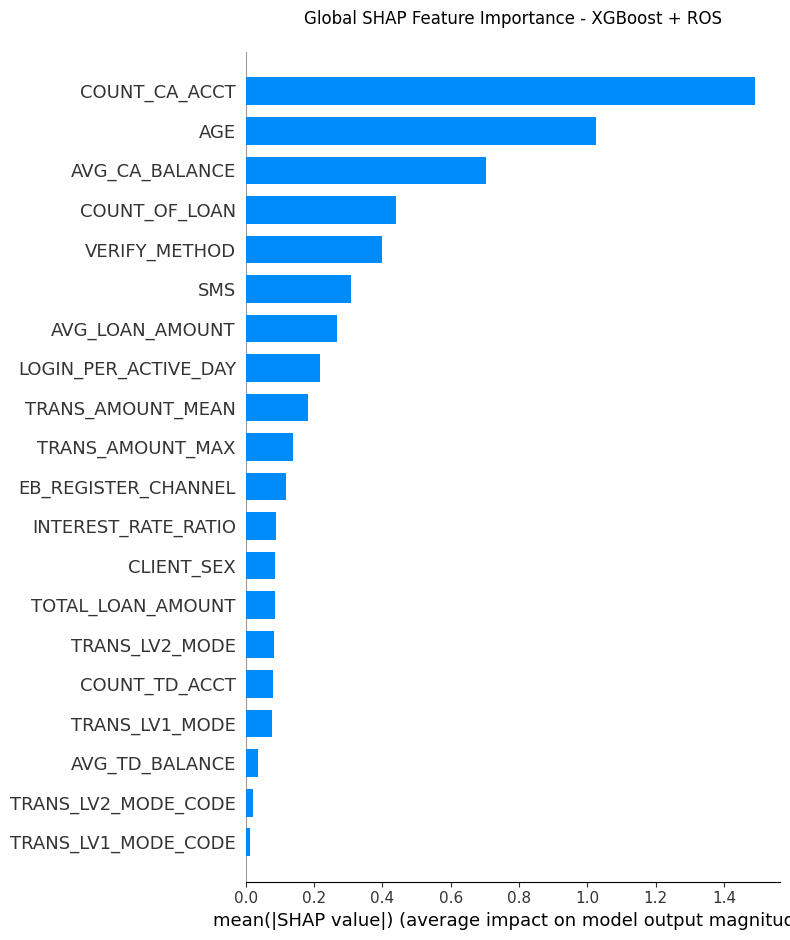


===== TOP SHAP FEATURES: XGBOOST + ROS =====
                 Feature  MeanAbsSHAP
13         COUNT_CA_ACCT     1.488658
4                    AGE     1.024078
14        AVG_CA_BALANCE     0.702124
17         COUNT_OF_LOAN     0.441231
3          VERIFY_METHOD     0.398063
2                    SMS     0.307781
18       AVG_LOAN_AMOUNT     0.266824
5   LOGIN_PER_ACTIVE_DAY     0.216627
10     TRANS_AMOUNT_MEAN     0.181611
9       TRANS_AMOUNT_MAX     0.139893

Top SHAP feature: COUNT_CA_ACCT


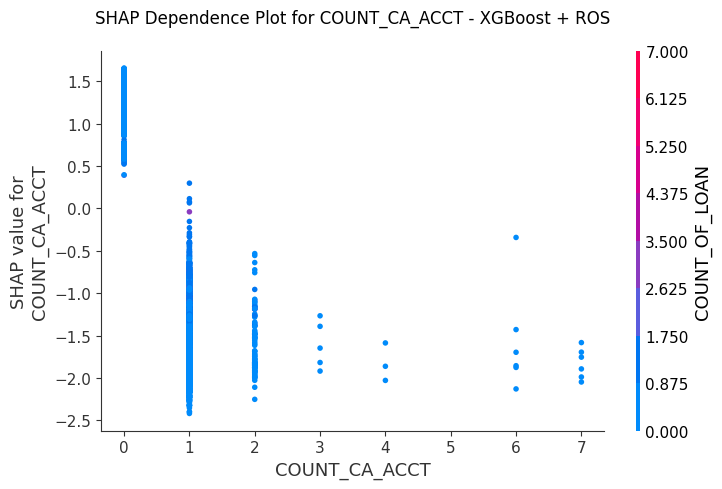


===== SAVED FILES =====
xgboost_ros_cv_results.csv
xgboost_ros_test_results.csv
roc_curve_xgboost_ros.png
decile_table_xgboost_ros.csv
decile_adoption_rate_xgboost_ros.png
decile_lift_xgboost_ros.png
precision_at_k_xgboost_ros.csv
precision_at_k_xgboost_ros.png
shap_summary_xgboost_ros.png
shap_bar_xgboost_ros.png
shap_feature_importance_xgboost_ros.csv
shap_dependence_COUNT_CA_ACCT_xgboost_ros.png


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix,
    roc_curve, recall_score, f1_score, accuracy_score
)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from xgboost import XGBClassifier

from imblearn.over_sampling import RandomOverSampler

# =========================
# 1. LOAD DATA
# =========================
# Nếu dùng file đã xóa AUTO-JOB:
df = pd.read_csv("final_dataset_no_auto_job.csv", low_memory=False)

# Nếu dùng file gốc thì đổi thành:
# df = pd.read_csv("final_dataset1.csv", low_memory=False)

df.columns = df.columns.str.strip()

df = df.replace(
    ["", " ", "NA", "N/A", "na", "null", "NULL", "None", "none"],
    np.nan
)

# =========================
# 2. TARGET
# =========================
target_col = "COUNT_CREDITCARD"
id_col = "CUSTOMER_NUMBER"

df[target_col] = pd.to_numeric(df[target_col], errors="coerce")
df = df.dropna(subset=[target_col]).copy()
df[target_col] = (df[target_col] > 0).astype(int)

# =========================
# 3. FEATURES
# =========================
drop_cols = [c for c in [id_col, target_col] if c in df.columns]
X = df.drop(columns=drop_cols).copy()
y = df[target_col].copy()

# =========================
# 4. HARMONIZE COLUMN TYPES
# =========================
for col in X.columns:
    if X[col].dtype == "object":
        converted = pd.to_numeric(X[col], errors="coerce")
        non_null_original = X[col].notna().sum()
        non_null_converted = converted.notna().sum()

        if non_null_original > 0 and (non_null_converted / non_null_original) >= 0.8:
            X[col] = converted
        else:
            X[col] = X[col].astype("string")

cat_cols = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

print("Categorical columns:", cat_cols)
print("Numerical columns:", num_cols)
print("Dataset shape:", df.shape)
print("Target distribution:")
print(y.value_counts(normalize=True))

# =========================
# 5. TRAIN / TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# =========================
# 6. MODEL: XGBOOST + ROS
# =========================
model_name = "XGBoost + RandomOverSampling (ROS)"

def get_xgb_model():
    return XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )

ros = RandomOverSampler(random_state=42)

# =========================
# 7. PREPROCESS FUNCTION
# =========================
def fit_preprocess(X_tr, X_val, cat_cols):
    X_tr = X_tr.copy()
    X_val = X_val.copy()

    for col in cat_cols:
        X_tr[col] = X_tr[col].astype("string")
        X_val[col] = X_val[col].astype("string")

    encoder = None
    if len(cat_cols) > 0:
        encoder = OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1,
            encoded_missing_value=-1
        )
        X_tr[cat_cols] = encoder.fit_transform(X_tr[cat_cols])
        X_val[cat_cols] = encoder.transform(X_val[cat_cols])

    imputer = SimpleImputer(strategy="median")

    X_tr = pd.DataFrame(
        imputer.fit_transform(X_tr),
        columns=X_tr.columns,
        index=X_tr.index
    )

    X_val = pd.DataFrame(
        imputer.transform(X_val),
        columns=X_val.columns,
        index=X_val.index
    )

    return X_tr, X_val, imputer, encoder

# =========================
# 8. CROSS-VALIDATION FOR XGBOOST + ROS
# =========================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

recall_scores = []
f1_scores = []
auc_scores = []
acc_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), start=1):
    X_tr = X_train.iloc[train_idx].copy()
    X_val = X_train.iloc[val_idx].copy()
    y_tr = y_train.iloc[train_idx].copy()
    y_val = y_train.iloc[val_idx].copy()

    X_tr_prep, X_val_prep, _, _ = fit_preprocess(X_tr, X_val, cat_cols)

    X_tr_res, y_tr_res = ros.fit_resample(X_tr_prep, y_tr)

    model = get_xgb_model()
    model.fit(X_tr_res, y_tr_res)

    y_val_prob = model.predict_proba(X_val_prep)[:, 1]
    y_val_pred = (y_val_prob >= 0.5).astype(int)

    recall = recall_score(y_val, y_val_pred, zero_division=0)
    f1 = f1_score(y_val, y_val_pred, zero_division=0)
    auc = roc_auc_score(y_val, y_val_prob)
    acc = accuracy_score(y_val, y_val_pred)

    recall_scores.append(recall)
    f1_scores.append(f1)
    auc_scores.append(auc)
    acc_scores.append(acc)

    print(f"Fold {fold} | Recall={recall:.4f} | F1={f1:.4f} | AUC={auc:.4f} | Accuracy={acc:.4f}")

cv_summary = pd.DataFrame([{
    "Model": model_name,
    "CV Recall": np.mean(recall_scores),
    "CV F1-score": np.mean(f1_scores),
    "CV AUC": np.mean(auc_scores),
    "CV Accuracy": np.mean(acc_scores),
    "Std (CV AUC)": np.std(auc_scores)
}])

print("\n===== CV RESULTS: XGBOOST + ROS =====")
print(cv_summary)

cv_summary.to_csv("xgboost_ros_cv_results.csv", index=False)

# =========================
# 9. FINAL TRAINING ON FULL TRAIN
# =========================
X_train_prep, X_test_prep, final_imputer, final_encoder = fit_preprocess(
    X_train,
    X_test,
    cat_cols
)

X_train_res, y_train_res = ros.fit_resample(X_train_prep, y_train)

final_model = get_xgb_model()
final_model.fit(X_train_res, y_train_res)

# =========================
# 10. TEST EVALUATION
# =========================
y_test_prob = final_model.predict_proba(X_test_prep)[:, 1]
y_test_pred = (y_test_prob >= 0.5).astype(int)

test_auc = roc_auc_score(y_test, y_test_prob)
test_recall = recall_score(y_test, y_test_pred, zero_division=0)
test_f1 = f1_score(y_test, y_test_pred, zero_division=0)
test_acc = accuracy_score(y_test, y_test_pred)
cm = confusion_matrix(y_test, y_test_pred)

test_summary = pd.DataFrame([{
    "Model": model_name,
    "Test Recall": test_recall,
    "Test F1-score": test_f1,
    "Test AUC": test_auc,
    "Test Accuracy": test_acc
}])

print("\n===== TEST RESULTS: XGBOOST + ROS =====")
print(test_summary)
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n")
print(classification_report(y_test, y_test_pred, digits=4))

test_summary.to_csv("xgboost_ros_test_results.csv", index=False)

# =========================
# 11. ROC CURVE - GHI RÕ MÔ HÌNH
# =========================
fpr, tpr, _ = roc_curve(y_test, y_test_prob)

plt.figure(figsize=(7, 5))
plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"XGBoost + ROS (AUC = {test_auc:.3f})"
)
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1,
    label="Random baseline"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost + RandomOverSampling (ROS)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("roc_curve_xgboost_ros.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================
# 12. DECILE ANALYSIS
# =========================
def create_decile_table(y_true, y_prob, n_groups=10):
    decile_df = pd.DataFrame({
        "y_true": np.asarray(y_true),
        "y_prob": np.asarray(y_prob)
    }).sort_values("y_prob", ascending=False).reset_index(drop=True)

    decile_df["Decile"] = pd.qcut(
        decile_df.index + 1,
        q=n_groups,
        labels=[f"D{i}" for i in range(1, n_groups + 1)]
    )

    decile_summary = decile_df.groupby("Decile", observed=False).agg(
        Customers=("y_true", "count"),
        Positives=("y_true", "sum"),
        Adoption_Rate=("y_true", "mean"),
        Avg_Pred_Prob=("y_prob", "mean")
    ).reset_index()

    overall_rate = decile_df["y_true"].mean()
    decile_summary["Lift"] = decile_summary["Adoption_Rate"] / overall_rate

    return decile_summary, overall_rate

decile_table_df, overall_rate = create_decile_table(y_test, y_test_prob)

print("\n===== DECILE TABLE: XGBOOST + ROS =====")
print(decile_table_df)

decile_table_df.to_csv("decile_table_xgboost_ros.csv", index=False)

# Adoption rate by decile
plt.figure(figsize=(8, 5))
plt.plot(
    decile_table_df["Decile"],
    decile_table_df["Adoption_Rate"],
    marker="o",
    linewidth=2,
    label="XGBoost + ROS"
)
plt.axhline(
    y=overall_rate,
    linestyle="--",
    label=f"Overall rate = {overall_rate:.3f}"
)
plt.xlabel("Decile (D1 = Top 10%)")
plt.ylabel("Adoption Rate")
plt.title("Adoption Rate by Prediction Decile - XGBoost + ROS")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("decile_adoption_rate_xgboost_ros.png", dpi=300, bbox_inches="tight")
plt.show()

# Lift by decile
plt.figure(figsize=(8, 5))
plt.plot(
    decile_table_df["Decile"],
    decile_table_df["Lift"],
    marker="o",
    linewidth=2,
    label="XGBoost + ROS"
)
plt.axhline(
    y=1.0,
    linestyle="--",
    label="Baseline lift = 1"
)
plt.xlabel("Decile (D1 = Top 10%)")
plt.ylabel("Lift")
plt.title("Lift by Prediction Decile - XGBoost + ROS")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("decile_lift_xgboost_ros.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================
# 13. PRECISION@TOP-K
# =========================
def precision_at_k(y_true, y_prob, top_rates=[0.10, 0.20, 0.30]):
    result_df = pd.DataFrame({
        "y_true": np.asarray(y_true),
        "y_prob": np.asarray(y_prob)
    }).sort_values("y_prob", ascending=False).reset_index(drop=True)

    rows = []
    n = len(result_df)

    for rate in top_rates:
        k = int(np.ceil(n * rate))
        top_df = result_df.iloc[:k]

        rows.append({
            "Model": model_name,
            "Top_K": f"Top {int(rate * 100)}%",
            "Customers": k,
            "Precision": top_df["y_true"].mean(),
            "Captured_Positives": top_df["y_true"].sum(),
            "Capture_Rate": top_df["y_true"].sum() / result_df["y_true"].sum()
        })

    return pd.DataFrame(rows)

precision_k_df = precision_at_k(y_test, y_test_prob)

print("\n===== PRECISION@TOP-K: XGBOOST + ROS =====")
print(precision_k_df)

precision_k_df.to_csv("precision_at_k_xgboost_ros.csv", index=False)

plt.figure(figsize=(7, 5))
plt.bar(
    precision_k_df["Top_K"],
    precision_k_df["Precision"]
)
plt.ylim(0, 1)
plt.xlabel("Targeting Threshold")
plt.ylabel("Precision")
plt.title("Precision@Top-K - XGBoost + ROS")

for i, v in enumerate(precision_k_df["Precision"]):
    plt.text(i, v + 0.02, f"{v:.3f}", ha="center")

plt.tight_layout()
plt.savefig("precision_at_k_xgboost_ros.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================
# 14. SHAP ANALYSIS
# =========================
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test_prep)

if isinstance(shap_values, list):
    shap_values = shap_values[1]

# SHAP summary plot
plt.figure()
shap.summary_plot(
    shap_values,
    X_test_prep,
    show=False
)
plt.title("SHAP Summary Plot - XGBoost + ROS", pad=20)
plt.tight_layout()
plt.savefig("shap_summary_xgboost_ros.png", dpi=300, bbox_inches="tight")
plt.show()

# SHAP bar plot
plt.figure()
shap.summary_plot(
    shap_values,
    X_test_prep,
    plot_type="bar",
    show=False
)
plt.title("Global SHAP Feature Importance - XGBoost + ROS", pad=20)
plt.tight_layout()
plt.savefig("shap_bar_xgboost_ros.png", dpi=300, bbox_inches="tight")
plt.show()

# Mean absolute SHAP importance
mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_importance_df = pd.DataFrame({
    "Feature": X_test_prep.columns,
    "MeanAbsSHAP": mean_abs_shap
}).sort_values("MeanAbsSHAP", ascending=False)

print("\n===== TOP SHAP FEATURES: XGBOOST + ROS =====")
print(shap_importance_df.head(10))

shap_importance_df.to_csv("shap_feature_importance_xgboost_ros.csv", index=False)

# Dependence plot for top feature
top_feature = shap_importance_df.iloc[0]["Feature"]
print("\nTop SHAP feature:", top_feature)

shap.dependence_plot(
    top_feature,
    shap_values,
    X_test_prep,
    show=False
)
plt.title(f"SHAP Dependence Plot for {top_feature} - XGBoost + ROS", pad=20)
plt.tight_layout()
plt.savefig(f"shap_dependence_{top_feature}_xgboost_ros.png", dpi=300, bbox_inches="tight")
plt.show()

print("\n===== SAVED FILES =====")
print("xgboost_ros_cv_results.csv")
print("xgboost_ros_test_results.csv")
print("roc_curve_xgboost_ros.png")
print("decile_table_xgboost_ros.csv")
print("decile_adoption_rate_xgboost_ros.png")
print("decile_lift_xgboost_ros.png")
print("precision_at_k_xgboost_ros.csv")
print("precision_at_k_xgboost_ros.png")
print("shap_summary_xgboost_ros.png")
print("shap_bar_xgboost_ros.png")
print("shap_feature_importance_xgboost_ros.csv")
print(f"shap_dependence_{top_feature}_xgboost_ros.png")

SHAP, DELICE, LIFT,ROC

Categorical columns: ['CLIENT_SEX', 'EB_REGISTER_CHANNEL', 'SMS', 'VERIFY_METHOD', 'TRANS_LV1_MODE', 'TRANS_LV2_MODE']
Numerical columns: ['AGE', 'LOGIN_PER_ACTIVE_DAY', 'INTEREST_RATE_RATIO', 'TRANS_AMOUNT_MAX', 'TRANS_AMOUNT_MEAN', 'TRANS_LV1_MODE_CODE', 'TRANS_LV2_MODE_CODE', 'COUNT_CA_ACCT', 'AVG_CA_BALANCE', 'COUNT_TD_ACCT', 'AVG_TD_BALANCE', 'COUNT_OF_LOAN', 'AVG_LOAN_AMOUNT', 'TOTAL_LOAN_AMOUNT']
Dataset shape: (127460, 22)
Target distribution:
COUNT_CREDITCARD
0    0.845332
1    0.154668
Name: proportion, dtype: float64
Fold 1 | Recall=0.9331 | F1=0.6895 | AUC=0.9524 | Accuracy=0.8700
Fold 2 | Recall=0.9280 | F1=0.6822 | AUC=0.9498 | Accuracy=0.8663
Fold 3 | Recall=0.9283 | F1=0.6827 | AUC=0.9505 | Accuracy=0.8665
Fold 4 | Recall=0.9236 | F1=0.6859 | AUC=0.9488 | Accuracy=0.8692
Fold 5 | Recall=0.9261 | F1=0.6898 | AUC=0.9523 | Accuracy=0.8712

===== CV RESULTS: XGBOOST + ROS =====
                                Model  CV Recall  CV F1-score    CV AUC  \
0  XGBoost + RandomOve

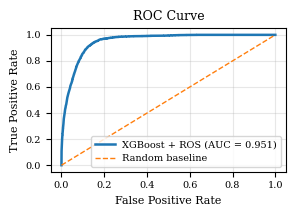


===== DECILE TABLE: XGBOOST + ROS =====
  Decile  Customers  Positives  Adoption_Rate  Avg_Pred_Prob      Lift
0     D1       2550       1993       0.781569       0.942235  5.052941
1     D2       2549       1226       0.480973       0.828497  3.109552
2     D3       2549        579       0.227148       0.544064  1.468540
3     D4       2549         93       0.036485       0.142864  0.235880
4     D5       2549         21       0.008239       0.047451  0.053263
5     D6       2549         18       0.007062       0.022893  0.045654
6     D7       2549         13       0.005100       0.011192  0.032972
7     D8       2549          0       0.000000       0.006057  0.000000
8     D9       2549          0       0.000000       0.002931  0.000000
9    D10       2550          0       0.000000       0.000690  0.000000


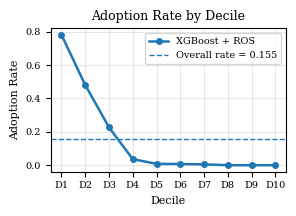

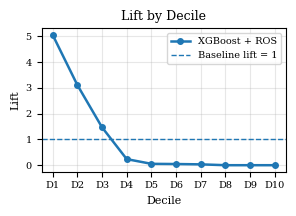


===== PRECISION@TOP-K: XGBOOST + ROS =====
                                Model    Top_K  Customers  Precision  \
0  XGBoost + RandomOverSampling (ROS)  Top 10%       2550   0.781569   
1  XGBoost + RandomOverSampling (ROS)  Top 20%       5099   0.631300   
2  XGBoost + RandomOverSampling (ROS)  Top 30%       7648   0.496600   

   Captured_Positives  Capture_Rate  
0                1993      0.505453  
1                3219      0.816383  
2                3798      0.963226  


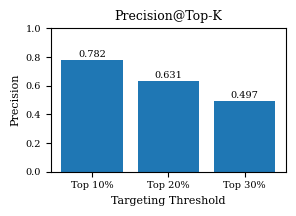

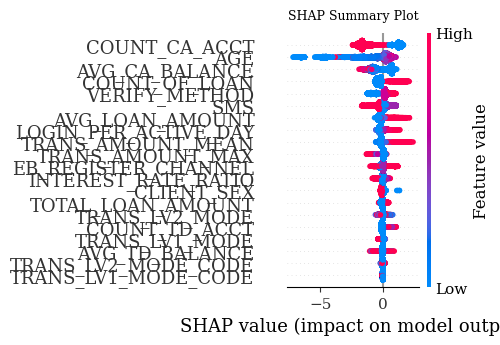

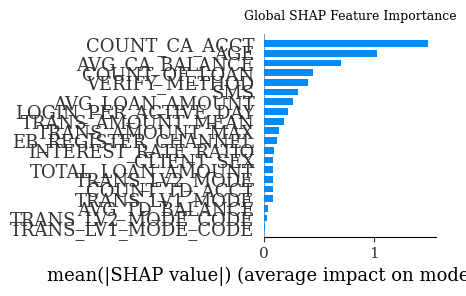


===== TOP SHAP FEATURES: XGBOOST + ROS =====
                 Feature  MeanAbsSHAP
13         COUNT_CA_ACCT     1.488658
4                    AGE     1.024078
14        AVG_CA_BALANCE     0.702124
17         COUNT_OF_LOAN     0.441231
3          VERIFY_METHOD     0.398063
2                    SMS     0.307781
18       AVG_LOAN_AMOUNT     0.266824
5   LOGIN_PER_ACTIVE_DAY     0.216627
10     TRANS_AMOUNT_MEAN     0.181611
9       TRANS_AMOUNT_MAX     0.139893

Top SHAP feature: COUNT_CA_ACCT


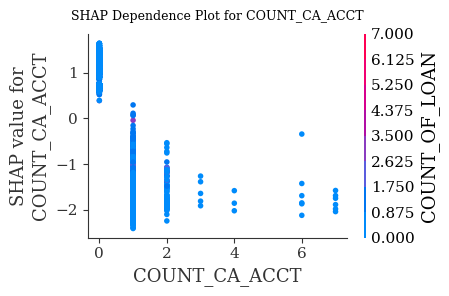


===== SAVED FILES =====
xgboost_ros_cv_results.csv
xgboost_ros_test_results.csv
decile_table_xgboost_ros.csv
precision_at_k_xgboost_ros.csv
shap_feature_importance_xgboost_ros.csv

Figures saved in folder: paper_figures


In [ ]:
# ==========================================================
# XGBOOST + ROS WITH PAPER-READY FIGURES
# TARGET: COUNT_CREDITCARD
# ==========================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix,
    roc_curve, recall_score, f1_score, accuracy_score
)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from xgboost import XGBClassifier

from imblearn.over_sampling import RandomOverSampler

# ==========================================================
# FIGURE SETTINGS FOR JOURNAL PAPER
# ==========================================================

FIG_DIR = "paper_figures"
os.makedirs(FIG_DIR, exist_ok=True)

DPI = 600

FIG_SMALL = (3.0, 2.2)     # ROC, Decile, Lift, Precision@K
FIG_MEDIUM = (4.5, 3.0)    # SHAP bar, SHAP dependence
FIG_LARGE = (5.0, 3.5)     # SHAP summary

plt.rcParams.update({
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.labelsize": 8,
    "legend.fontsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7
})

def save_fig(filename):
    plt.tight_layout()
    plt.savefig(
        os.path.join(FIG_DIR, filename),
        dpi=DPI,
        bbox_inches="tight",
        pad_inches=0.02
    )
    plt.show()


# ==========================================================
# 1. LOAD DATA
# ==========================================================

df = pd.read_csv("final_dataset_no_auto_job.csv", low_memory=False)

df.columns = df.columns.str.strip()

df = df.replace(
    ["", " ", "NA", "N/A", "na", "null", "NULL", "None", "none"],
    np.nan
)

# ==========================================================
# 2. TARGET
# ==========================================================

target_col = "COUNT_CREDITCARD"
id_col = "CUSTOMER_NUMBER"

df[target_col] = pd.to_numeric(df[target_col], errors="coerce")
df = df.dropna(subset=[target_col]).copy()
df[target_col] = (df[target_col] > 0).astype(int)

# ==========================================================
# 3. FEATURES
# ==========================================================

drop_cols = [c for c in [id_col, target_col] if c in df.columns]
X = df.drop(columns=drop_cols).copy()
y = df[target_col].copy()

# ==========================================================
# 4. HARMONIZE COLUMN TYPES
# ==========================================================

for col in X.columns:
    if X[col].dtype == "object":
        converted = pd.to_numeric(X[col], errors="coerce")
        non_null_original = X[col].notna().sum()
        non_null_converted = converted.notna().sum()

        if non_null_original > 0 and (non_null_converted / non_null_original) >= 0.8:
            X[col] = converted
        else:
            X[col] = X[col].astype("string")

cat_cols = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

print("Categorical columns:", cat_cols)
print("Numerical columns:", num_cols)
print("Dataset shape:", df.shape)
print("Target distribution:")
print(y.value_counts(normalize=True))

# ==========================================================
# 5. TRAIN / TEST SPLIT
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# ==========================================================
# 6. MODEL: XGBOOST + ROS
# ==========================================================

model_name = "XGBoost + RandomOverSampling (ROS)"

def get_xgb_model():
    return XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )

ros = RandomOverSampler(random_state=42)

# ==========================================================
# 7. PREPROCESS FUNCTION
# ==========================================================

def fit_preprocess(X_tr, X_val, cat_cols):
    X_tr = X_tr.copy()
    X_val = X_val.copy()

    for col in cat_cols:
        X_tr[col] = X_tr[col].astype("string")
        X_val[col] = X_val[col].astype("string")

    encoder = None

    if len(cat_cols) > 0:
        encoder = OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1,
            encoded_missing_value=-1
        )
        X_tr[cat_cols] = encoder.fit_transform(X_tr[cat_cols])
        X_val[cat_cols] = encoder.transform(X_val[cat_cols])

    imputer = SimpleImputer(strategy="median")

    X_tr = pd.DataFrame(
        imputer.fit_transform(X_tr),
        columns=X_tr.columns,
        index=X_tr.index
    )

    X_val = pd.DataFrame(
        imputer.transform(X_val),
        columns=X_val.columns,
        index=X_val.index
    )

    return X_tr, X_val, imputer, encoder

# ==========================================================
# 8. CROSS-VALIDATION FOR XGBOOST + ROS
# ==========================================================

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

recall_scores = []
f1_scores = []
auc_scores = []
acc_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), start=1):

    X_tr = X_train.iloc[train_idx].copy()
    X_val = X_train.iloc[val_idx].copy()
    y_tr = y_train.iloc[train_idx].copy()
    y_val = y_train.iloc[val_idx].copy()

    X_tr_prep, X_val_prep, _, _ = fit_preprocess(X_tr, X_val, cat_cols)

    X_tr_res, y_tr_res = ros.fit_resample(X_tr_prep, y_tr)

    model = get_xgb_model()
    model.fit(X_tr_res, y_tr_res)

    y_val_prob = model.predict_proba(X_val_prep)[:, 1]

    threshold = 0.5
    y_val_pred = (y_val_prob >= threshold).astype(int)

    recall = recall_score(y_val, y_val_pred, zero_division=0)
    f1 = f1_score(y_val, y_val_pred, zero_division=0)
    auc = roc_auc_score(y_val, y_val_prob)
    acc = accuracy_score(y_val, y_val_pred)

    recall_scores.append(recall)
    f1_scores.append(f1)
    auc_scores.append(auc)
    acc_scores.append(acc)

    print(
        f"Fold {fold} | "
        f"Recall={recall:.4f} | "
        f"F1={f1:.4f} | "
        f"AUC={auc:.4f} | "
        f"Accuracy={acc:.4f}"
    )

cv_summary = pd.DataFrame([{
    "Model": model_name,
    "CV Recall": np.mean(recall_scores),
    "CV F1-score": np.mean(f1_scores),
    "CV AUC": np.mean(auc_scores),
    "CV Accuracy": np.mean(acc_scores),
    "Std (CV AUC)": np.std(auc_scores)
}])

print("\n===== CV RESULTS: XGBOOST + ROS =====")
print(cv_summary)

cv_summary.to_csv("xgboost_ros_cv_results.csv", index=False)

# ==========================================================
# 9. FINAL TRAINING ON FULL TRAINING SET
# ==========================================================

X_train_prep, X_test_prep, final_imputer, final_encoder = fit_preprocess(
    X_train,
    X_test,
    cat_cols
)

X_train_res, y_train_res = ros.fit_resample(X_train_prep, y_train)

final_model = get_xgb_model()
final_model.fit(X_train_res, y_train_res)

# ==========================================================
# 10. TEST EVALUATION
# ==========================================================

y_test_prob = final_model.predict_proba(X_test_prep)[:, 1]

threshold = 0.5
y_test_pred = (y_test_prob >= threshold).astype(int)

test_auc = roc_auc_score(y_test, y_test_prob)
test_recall = recall_score(y_test, y_test_pred, zero_division=0)
test_f1 = f1_score(y_test, y_test_pred, zero_division=0)
test_acc = accuracy_score(y_test, y_test_pred)
cm = confusion_matrix(y_test, y_test_pred)

test_summary = pd.DataFrame([{
    "Model": model_name,
    "Decision Threshold": threshold,
    "Test Recall": test_recall,
    "Test F1-score": test_f1,
    "Test AUC": test_auc,
    "Test Accuracy": test_acc
}])

print("\n===== TEST RESULTS: XGBOOST + ROS =====")
print(test_summary)
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n")
print(classification_report(y_test, y_test_pred, digits=4))

test_summary.to_csv("xgboost_ros_test_results.csv", index=False)

# ==========================================================
# 11. ROC CURVE
# ==========================================================

fpr, tpr, _ = roc_curve(y_test, y_test_prob)

plt.figure(figsize=FIG_SMALL)

plt.plot(
    fpr,
    tpr,
    linewidth=1.8,
    label=f"XGBoost + ROS (AUC = {test_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1,
    label="Random baseline"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

save_fig("roc_curve_xgboost_ros.png")

# ==========================================================
# 12. DECILE ANALYSIS
# ==========================================================

def create_decile_table(y_true, y_prob, n_groups=10):
    decile_df = pd.DataFrame({
        "y_true": np.asarray(y_true),
        "y_prob": np.asarray(y_prob)
    }).sort_values("y_prob", ascending=False).reset_index(drop=True)

    decile_df["Decile"] = pd.qcut(
        decile_df.index + 1,
        q=n_groups,
        labels=[f"D{i}" for i in range(1, n_groups + 1)]
    )

    decile_summary = decile_df.groupby("Decile", observed=False).agg(
        Customers=("y_true", "count"),
        Positives=("y_true", "sum"),
        Adoption_Rate=("y_true", "mean"),
        Avg_Pred_Prob=("y_prob", "mean")
    ).reset_index()

    overall_rate = decile_df["y_true"].mean()
    decile_summary["Lift"] = decile_summary["Adoption_Rate"] / overall_rate

    return decile_summary, overall_rate

decile_table_df, overall_rate = create_decile_table(y_test, y_test_prob)

print("\n===== DECILE TABLE: XGBOOST + ROS =====")
print(decile_table_df)

decile_table_df.to_csv("decile_table_xgboost_ros.csv", index=False)

# Adoption rate by decile
plt.figure(figsize=FIG_SMALL)

plt.plot(
    decile_table_df["Decile"],
    decile_table_df["Adoption_Rate"],
    marker="o",
    linewidth=1.8,
    markersize=4,
    label="XGBoost + ROS"
)

plt.axhline(
    y=overall_rate,
    linestyle="--",
    linewidth=1,
    label=f"Overall rate = {overall_rate:.3f}"
)

plt.xlabel("Decile")
plt.ylabel("Adoption Rate")
plt.title("Adoption Rate by Decile")
plt.legend()
plt.grid(alpha=0.3)

save_fig("decile_adoption_rate_xgboost_ros.png")

# Lift by decile
plt.figure(figsize=FIG_SMALL)

plt.plot(
    decile_table_df["Decile"],
    decile_table_df["Lift"],
    marker="o",
    linewidth=1.8,
    markersize=4,
    label="XGBoost + ROS"
)

plt.axhline(
    y=1.0,
    linestyle="--",
    linewidth=1,
    label="Baseline lift = 1"
)

plt.xlabel("Decile")
plt.ylabel("Lift")
plt.title("Lift by Decile")
plt.legend()
plt.grid(alpha=0.3)

save_fig("decile_lift_xgboost_ros.png")

# ==========================================================
# 13. PRECISION@TOP-K
# ==========================================================

def precision_at_k(y_true, y_prob, top_rates=[0.10, 0.20, 0.30]):
    result_df = pd.DataFrame({
        "y_true": np.asarray(y_true),
        "y_prob": np.asarray(y_prob)
    }).sort_values("y_prob", ascending=False).reset_index(drop=True)

    rows = []
    n = len(result_df)

    for rate in top_rates:
        k = int(np.ceil(n * rate))
        top_df = result_df.iloc[:k]

        rows.append({
            "Model": model_name,
            "Top_K": f"Top {int(rate * 100)}%",
            "Customers": k,
            "Precision": top_df["y_true"].mean(),
            "Captured_Positives": top_df["y_true"].sum(),
            "Capture_Rate": top_df["y_true"].sum() / result_df["y_true"].sum()
        })

    return pd.DataFrame(rows)

precision_k_df = precision_at_k(y_test, y_test_prob)

print("\n===== PRECISION@TOP-K: XGBOOST + ROS =====")
print(precision_k_df)

precision_k_df.to_csv("precision_at_k_xgboost_ros.csv", index=False)

plt.figure(figsize=FIG_SMALL)

plt.bar(
    precision_k_df["Top_K"],
    precision_k_df["Precision"]
)

plt.ylim(0, 1)
plt.xlabel("Targeting Threshold")
plt.ylabel("Precision")
plt.title("Precision@Top-K")

for i, v in enumerate(precision_k_df["Precision"]):
    plt.text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=7)

save_fig("precision_at_k_xgboost_ros.png")

# ==========================================================
# 14. SHAP ANALYSIS
# ==========================================================

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test_prep)

if isinstance(shap_values, list):
    shap_values = shap_values[1]

# SHAP summary plot
shap.summary_plot(
    shap_values,
    X_test_prep,
    show=False,
    plot_size=FIG_LARGE
)

plt.title("SHAP Summary Plot", pad=10)
save_fig("shap_summary_xgboost_ros.png")

# SHAP bar plot
shap.summary_plot(
    shap_values,
    X_test_prep,
    plot_type="bar",
    show=False,
    plot_size=FIG_MEDIUM
)

plt.title("Global SHAP Feature Importance", pad=10)
save_fig("shap_bar_xgboost_ros.png")

# Mean absolute SHAP importance
mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_importance_df = pd.DataFrame({
    "Feature": X_test_prep.columns,
    "MeanAbsSHAP": mean_abs_shap
}).sort_values("MeanAbsSHAP", ascending=False)

print("\n===== TOP SHAP FEATURES: XGBOOST + ROS =====")
print(shap_importance_df.head(10))

shap_importance_df.to_csv("shap_feature_importance_xgboost_ros.csv", index=False)

# SHAP dependence plot for top feature
top_feature = shap_importance_df.iloc[0]["Feature"]
print("\nTop SHAP feature:", top_feature)

shap.dependence_plot(
    top_feature,
    shap_values,
    X_test_prep,
    show=False
)

plt.gcf().set_size_inches(*FIG_MEDIUM)
plt.title(f"SHAP Dependence Plot for {top_feature}", pad=10)

save_fig(f"shap_dependence_{top_feature}_xgboost_ros.png")

# ==========================================================
# 15. SAVED FILES
# ==========================================================

print("\n===== SAVED FILES =====")
print("xgboost_ros_cv_results.csv")
print("xgboost_ros_test_results.csv")
print("decile_table_xgboost_ros.csv")
print("precision_at_k_xgboost_ros.csv")
print("shap_feature_importance_xgboost_ros.csv")
print(f"\nFigures saved in folder: {FIG_DIR}")

Precision@K with 95% CI + Decile CI

In [ ]:
# ==========================================================
# XGBOOST + ROS + BOOTSTRAP 95% CI
# TARGET: COUNT_CREDITCARD
# ==========================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import roc_auc_score, recall_score, f1_score, accuracy_score

from xgboost import XGBClassifier
from imblearn.over_sampling import RandomOverSampler

# ==========================================================
# 1. LOAD DATA
# ==========================================================

df = pd.read_csv("final_dataset_no_auto_job.csv", low_memory=False)
df.columns = df.columns.str.strip()

df = df.replace(
    ["", " ", "NA", "N/A", "na", "null", "NULL", "None", "none"],
    np.nan
)

# ==========================================================
# 2. TARGET
# ==========================================================

target_col = "COUNT_CREDITCARD"
id_col = "CUSTOMER_NUMBER"

df[target_col] = pd.to_numeric(df[target_col], errors="coerce")
df = df.dropna(subset=[target_col]).copy()
df[target_col] = (df[target_col] > 0).astype(int)

# ==========================================================
# 3. FEATURES
# ==========================================================

drop_cols = [c for c in [id_col, target_col] if c in df.columns]

X = df.drop(columns=drop_cols).copy()
y = df[target_col].copy()

# ==========================================================
# 4. HANDLE DATA TYPES
# ==========================================================

for col in X.columns:
    if X[col].dtype == "object":
        converted = pd.to_numeric(X[col], errors="coerce")
        original_non_null = X[col].notna().sum()
        converted_non_null = converted.notna().sum()

        if original_non_null > 0 and converted_non_null / original_non_null >= 0.8:
            X[col] = converted
        else:
            X[col] = X[col].astype("string")

cat_cols = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()

# ==========================================================
# 5. TRAIN / TEST SPLIT
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# ==========================================================
# 6. PREPROCESSING FUNCTION
# ==========================================================

def fit_preprocess(X_tr, X_te, cat_cols):
    X_tr = X_tr.copy()
    X_te = X_te.copy()

    if len(cat_cols) > 0:
        for col in cat_cols:
            X_tr[col] = X_tr[col].astype("string")
            X_te[col] = X_te[col].astype("string")

        encoder = OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1,
            encoded_missing_value=-1
        )

        X_tr[cat_cols] = encoder.fit_transform(X_tr[cat_cols])
        X_te[cat_cols] = encoder.transform(X_te[cat_cols])
    else:
        encoder = None

    imputer = SimpleImputer(strategy="median")

    X_tr = pd.DataFrame(
        imputer.fit_transform(X_tr),
        columns=X_tr.columns,
        index=X_tr.index
    )

    X_te = pd.DataFrame(
        imputer.transform(X_te),
        columns=X_te.columns,
        index=X_te.index
    )

    return X_tr, X_te, imputer, encoder

X_train_prep, X_test_prep, imputer, encoder = fit_preprocess(
    X_train,
    X_test,
    cat_cols
)

# ==========================================================
# 7. RANDOM OVERSAMPLING
# ==========================================================

ros = RandomOverSampler(random_state=42)

X_train_res, y_train_res = ros.fit_resample(
    X_train_prep,
    y_train
)

# ==========================================================
# 8. TRAIN XGBOOST
# ==========================================================

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_res, y_train_res)

# ==========================================================
# 9. TEST PREDICTION
# ==========================================================

y_test_prob = model.predict_proba(X_test_prep)[:, 1]
y_test_pred = (y_test_prob >= 0.5).astype(int)

print("\n===== TEST PERFORMANCE =====")
print("Recall  :", round(recall_score(y_test, y_test_pred), 4))
print("F1-score:", round(f1_score(y_test, y_test_pred), 4))
print("AUC     :", round(roc_auc_score(y_test, y_test_prob), 4))
print("Accuracy:", round(accuracy_score(y_test, y_test_pred), 4))

# Save prediction-level file
prediction_df = pd.DataFrame({
    "y_true": y_test.values,
    "y_prob": y_test_prob
})

prediction_df.to_csv(
    "xgboost_ros_test_predictions.csv",
    index=False
)

# ==========================================================
# 10. DECILE TABLE
# ==========================================================

def create_decile_table(y_true, y_prob):
    df_rank = pd.DataFrame({
        "y_true": np.asarray(y_true),
        "y_prob": np.asarray(y_prob)
    }).sort_values("y_prob", ascending=False).reset_index(drop=True)

    df_rank["Decile"] = pd.qcut(
        df_rank.index + 1,
        q=10,
        labels=[f"D{i}" for i in range(1, 11)]
    )

    overall_rate = df_rank["y_true"].mean()

    decile_table = (
        df_rank
        .groupby("Decile", observed=False)
        .agg(
            Customers=("y_true", "count"),
            Positives=("y_true", "sum"),
            Adoption_Rate=("y_true", "mean"),
            Avg_Pred_Prob=("y_prob", "mean")
        )
        .reset_index()
    )

    decile_table["Lift"] = decile_table["Adoption_Rate"] / overall_rate

    return decile_table, overall_rate

decile_table, overall_rate = create_decile_table(y_test, y_test_prob)

print("\n===== DECILE TABLE =====")
print(decile_table)

decile_table.to_csv(
    "decile_table_xgboost_ros.csv",
    index=False
)

# ==========================================================
# 11. PRECISION@K
# ==========================================================

def precision_at_k(y_true, y_prob, top_rates=[0.10, 0.20, 0.30]):
    df_rank = pd.DataFrame({
        "y_true": np.asarray(y_true),
        "y_prob": np.asarray(y_prob)
    }).sort_values("y_prob", ascending=False).reset_index(drop=True)

    n = len(df_rank)
    total_positives = df_rank["y_true"].sum()

    rows = []

    for rate in top_rates:
        k = int(np.ceil(n * rate))
        top_df = df_rank.iloc[:k]

        rows.append({
            "Metric": f"Precision@{int(rate * 100)}%",
            "Top_K": f"Top {int(rate * 100)}%",
            "Customers": k,
            "Estimate": top_df["y_true"].mean(),
            "Captured_Positives": top_df["y_true"].sum(),
            "Capture_Rate": top_df["y_true"].sum() / total_positives
        })

    return pd.DataFrame(rows)

precision_k = precision_at_k(y_test, y_test_prob)

print("\n===== PRECISION@K =====")
print(precision_k)

precision_k.to_csv(
    "precision_at_k_xgboost_ros.csv",
    index=False
)

# ==========================================================
# 12. BOOTSTRAP 95% CI
# ==========================================================

def bootstrap_ranking_ci(
    y_true,
    y_prob,
    top_rates=[0.10, 0.20, 0.30],
    n_bootstrap=1000,
    random_state=42
):
    rng = np.random.default_rng(random_state)

    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    n = len(y_true)

    decile_boot = {f"D{i}": [] for i in range(1, 11)}
    precision_boot = {
        f"Precision@{int(rate * 100)}%": []
        for rate in top_rates
    }

    for _ in range(n_bootstrap):
        idx = rng.choice(n, size=n, replace=True)

        boot_df = pd.DataFrame({
            "y_true": y_true[idx],
            "y_prob": y_prob[idx]
        }).sort_values("y_prob", ascending=False).reset_index(drop=True)

        boot_df["Decile"] = pd.qcut(
            boot_df.index + 1,
            q=10,
            labels=[f"D{i}" for i in range(1, 11)]
        )

        decile_rates = (
            boot_df
            .groupby("Decile", observed=False)["y_true"]
            .mean()
        )

        for d in decile_boot:
            decile_boot[d].append(decile_rates.loc[d])

        for rate in top_rates:
            k = int(np.ceil(n * rate))
            metric = f"Precision@{int(rate * 100)}%"
            precision_boot[metric].append(
                boot_df.iloc[:k]["y_true"].mean()
            )

    # Original estimates
    original_decile, _ = create_decile_table(y_true, y_prob)
    original_precision = precision_at_k(y_true, y_prob, top_rates)

    # Decile CI
    decile_ci_rows = []

    for d in decile_boot:
        values = np.array(decile_boot[d])

        estimate = original_decile.loc[
            original_decile["Decile"] == d,
            "Adoption_Rate"
        ].values[0]

        decile_ci_rows.append({
            "Decile": d,
            "Adoption_Rate": estimate,
            "CI_95_Lower": np.percentile(values, 2.5),
            "CI_95_Upper": np.percentile(values, 97.5)
        })

    decile_ci = pd.DataFrame(decile_ci_rows)

    # Precision CI
    precision_ci_rows = []

    for metric in precision_boot:
        values = np.array(precision_boot[metric])

        estimate = original_precision.loc[
            original_precision["Metric"] == metric,
            "Estimate"
        ].values[0]

        precision_ci_rows.append({
            "Metric": metric,
            "Estimate": estimate,
            "CI_95_Lower": np.percentile(values, 2.5),
            "CI_95_Upper": np.percentile(values, 97.5)
        })

    precision_ci = pd.DataFrame(precision_ci_rows)

    return decile_ci, precision_ci

decile_ci, precision_ci = bootstrap_ranking_ci(
    y_true=y_test,
    y_prob=y_test_prob,
    top_rates=[0.10, 0.20, 0.30],
    n_bootstrap=1000,
    random_state=42
)

# ==========================================================
# 13. FORMAT TABLES FOR PAPER
# ==========================================================

decile_ci_paper = decile_ci.copy()
precision_ci_paper = precision_ci.copy()

for col in ["Adoption_Rate", "CI_95_Lower", "CI_95_Upper"]:
    decile_ci_paper[col] = (decile_ci_paper[col] * 100).round(2)

for col in ["Estimate", "CI_95_Lower", "CI_95_Upper"]:
    precision_ci_paper[col] = precision_ci_paper[col].round(4)

print("\n===== DECILE ADOPTION RATE WITH 95% CI (%) =====")
print(decile_ci_paper)

print("\n===== PRECISION@K WITH 95% CI =====")
print(precision_ci_paper)

decile_ci_paper.to_csv(
    "decile_adoption_rate_bootstrap_ci.csv",
    index=False
)

precision_ci_paper.to_csv(
    "precision_at_k_bootstrap_ci.csv",
    index=False
)

print("\n===== SAVED FILES =====")
print("xgboost_ros_test_predictions.csv")
print("decile_table_xgboost_ros.csv")
print("precision_at_k_xgboost_ros.csv")
print("decile_adoption_rate_bootstrap_ci.csv")
print("precision_at_k_bootstrap_ci.csv")


===== TEST PERFORMANCE =====
Recall  : 0.929
F1-score: 0.6888
AUC     : 0.9508
Accuracy: 0.8702

===== DECILE TABLE =====
  Decile  Customers  Positives  Adoption_Rate  Avg_Pred_Prob      Lift
0     D1       2550       1993       0.781569       0.942235  5.052941
1     D2       2549       1226       0.480973       0.828497  3.109552
2     D3       2549        579       0.227148       0.544064  1.468540
3     D4       2549         93       0.036485       0.142864  0.235880
4     D5       2549         21       0.008239       0.047451  0.053263
5     D6       2549         18       0.007062       0.022893  0.045654
6     D7       2549         13       0.005100       0.011192  0.032972
7     D8       2549          0       0.000000       0.006057  0.000000
8     D9       2549          0       0.000000       0.002931  0.000000
9    D10       2550          0       0.000000       0.000690  0.000000

===== PRECISION@K =====
          Metric    Top_K  Customers  Estimate  Captured_Positives  \
0

SHAP

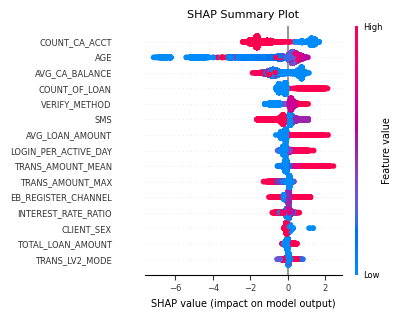

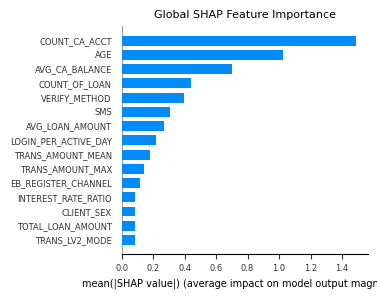


===== TOP 15 SHAP FEATURES: XGBOOST + ROS =====
                 Feature  MeanAbsSHAP
13         COUNT_CA_ACCT     1.488658
4                    AGE     1.024078
14        AVG_CA_BALANCE     0.702124
17         COUNT_OF_LOAN     0.441231
3          VERIFY_METHOD     0.398063
2                    SMS     0.307781
18       AVG_LOAN_AMOUNT     0.266824
5   LOGIN_PER_ACTIVE_DAY     0.216627
10     TRANS_AMOUNT_MEAN     0.181611
9       TRANS_AMOUNT_MAX     0.139893
1    EB_REGISTER_CHANNEL     0.119185
6    INTEREST_RATE_RATIO     0.088178
0             CLIENT_SEX     0.084841
19     TOTAL_LOAN_AMOUNT     0.084649
8         TRANS_LV2_MODE     0.084237

Top SHAP feature: COUNT_CA_ACCT


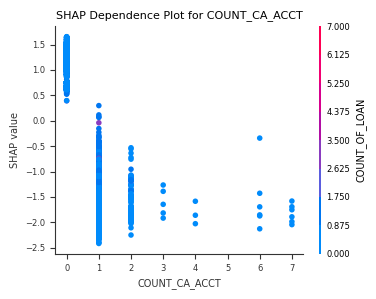

In [ ]:
# ==========================================================
# 14. SHAP ANALYSIS - JOURNAL 2-COLUMN VERSION, TOP 15
# ==========================================================

import os
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

FIG_DIR = "paper_figures"
os.makedirs(FIG_DIR, exist_ok=True)

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 7,
    "axes.titlesize": 8,
    "axes.labelsize": 7,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 6
})

DPI = 600

# Kích thước phù hợp để đặt 2 hình trên một hàng
SHAP_SUMMARY_SIZE = (4.2, 3.2)
SHAP_BAR_SIZE = (3.8, 3.0)
SHAP_DEP_SIZE = (3.8, 3.0)

MAX_DISPLAY = 15

# =========================
# COMPUTE SHAP VALUES
# =========================
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test_prep)

if isinstance(shap_values, list):
    shap_values = shap_values[1]

# =========================
# SHAP SUMMARY PLOT - TOP 15
# =========================
shap.summary_plot(
    shap_values,
    X_test_prep,
    show=False,
    plot_size=SHAP_SUMMARY_SIZE,
    max_display=MAX_DISPLAY
)

fig = plt.gcf()
fig.set_size_inches(*SHAP_SUMMARY_SIZE)

for ax in fig.axes:
    ax.tick_params(axis="both", labelsize=6)
    ax.xaxis.label.set_size(7)
    ax.yaxis.label.set_size(7)

plt.title("SHAP Summary Plot", fontsize=8, pad=6)

plt.tight_layout()
plt.savefig(
    os.path.join(FIG_DIR, "shap_summary_xgboost_ros_top15.png"),
    dpi=DPI,
    bbox_inches="tight",
    pad_inches=0.02
)
plt.show()

# =========================
# SHAP BAR PLOT - TOP 15
# =========================
shap.summary_plot(
    shap_values,
    X_test_prep,
    plot_type="bar",
    show=False,
    plot_size=SHAP_BAR_SIZE,
    max_display=MAX_DISPLAY
)

fig = plt.gcf()
fig.set_size_inches(*SHAP_BAR_SIZE)

for ax in fig.axes:
    ax.tick_params(axis="both", labelsize=6)
    ax.xaxis.label.set_size(7)
    ax.yaxis.label.set_size(7)

plt.title("Global SHAP Feature Importance", fontsize=8, pad=6)

plt.tight_layout()
plt.savefig(
    os.path.join(FIG_DIR, "shap_bar_xgboost_ros_top15.png"),
    dpi=DPI,
    bbox_inches="tight",
    pad_inches=0.02
)
plt.show()

# =========================
# MEAN ABSOLUTE SHAP IMPORTANCE - TOP 15
# =========================
mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_importance_df = pd.DataFrame({
    "Feature": X_test_prep.columns,
    "MeanAbsSHAP": mean_abs_shap
}).sort_values("MeanAbsSHAP", ascending=False)

print("\n===== TOP 15 SHAP FEATURES: XGBOOST + ROS =====")
print(shap_importance_df.head(MAX_DISPLAY))

shap_importance_df.to_csv(
    "shap_feature_importance_xgboost_ros_top15.csv",
    index=False
)

# =========================
# SHAP DEPENDENCE PLOT
# =========================
top_feature = shap_importance_df.iloc[0]["Feature"]
print("\nTop SHAP feature:", top_feature)

shap.dependence_plot(
    top_feature,
    shap_values,
    X_test_prep,
    show=False
)

fig = plt.gcf()
fig.set_size_inches(*SHAP_DEP_SIZE)

for ax in fig.axes:
    ax.tick_params(axis="both", labelsize=6)
    ax.xaxis.label.set_size(7)
    ax.yaxis.label.set_size(7)

plt.xlabel(top_feature, fontsize=7)
plt.ylabel("SHAP value", fontsize=7)
plt.title(f"SHAP Dependence Plot for {top_feature}", fontsize=8, pad=6)

plt.tight_layout()
plt.savefig(
    os.path.join(FIG_DIR, f"shap_dependence_{top_feature}_xgboost_ros.png"),
    dpi=DPI,
    bbox_inches="tight",
    pad_inches=0.02
)
plt.show()

Extended SHAP Analysis

/tmp/ipykernel_81037/1912756343.py:39: DtypeWarning: Columns (2,3,4,9,10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("final_dataset_no_auto_job.csv")


===== XGBoost + Random Oversampling =====
Recall   : 0.9270
F1-score : 0.6885
AUC      : 0.9510
Accuracy : 0.8703
Brier    : 0.09006
Model and imputer saved successfully.


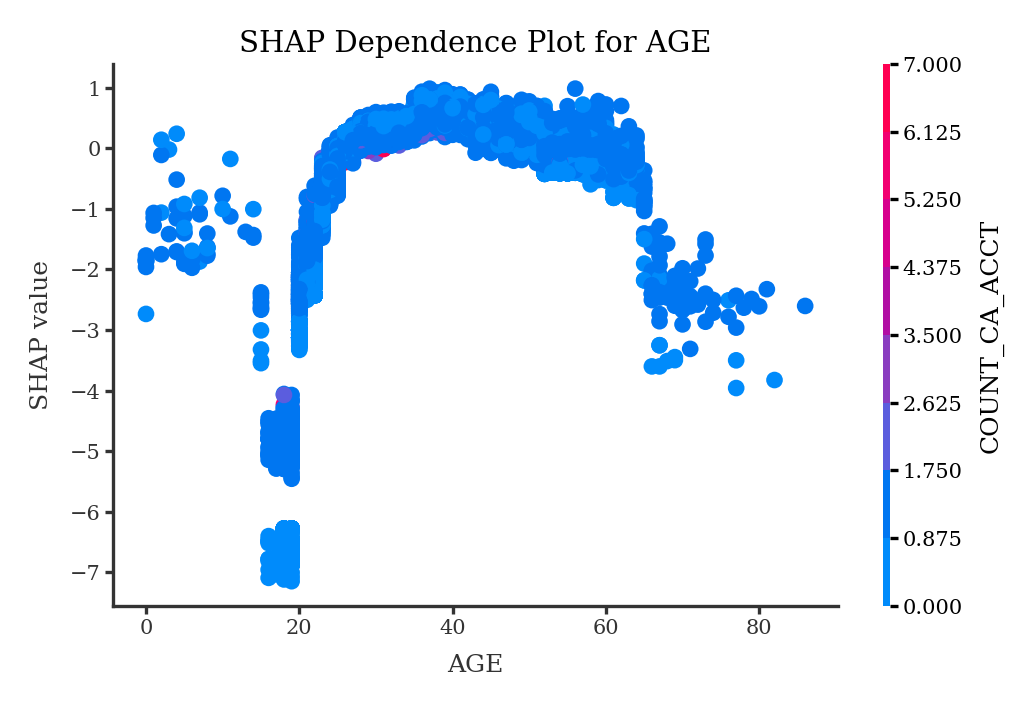

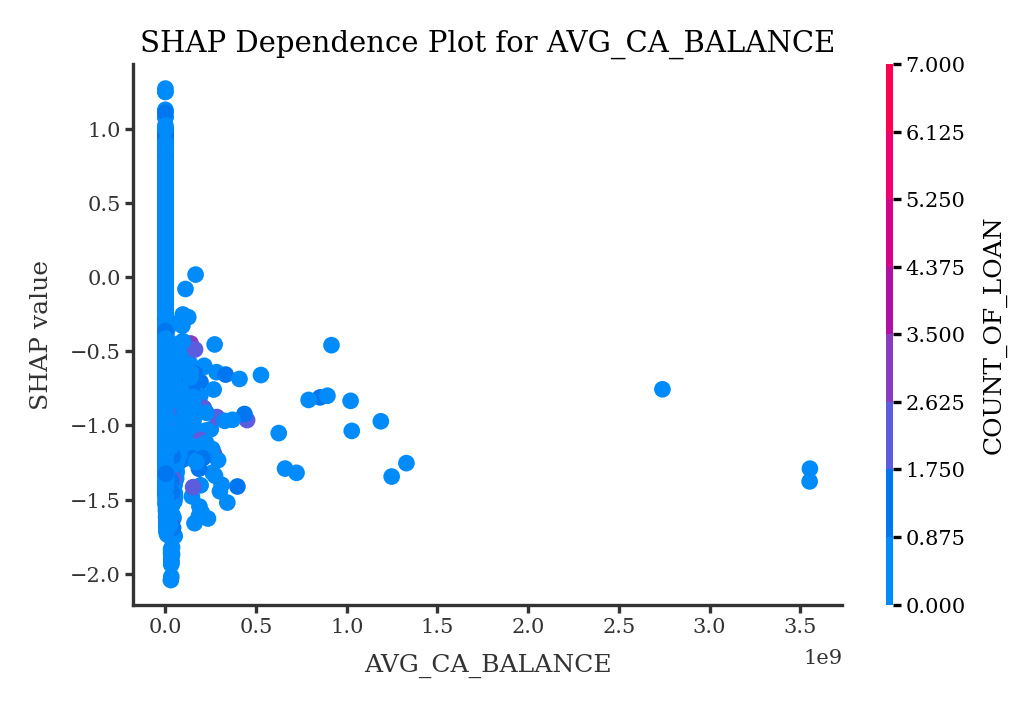

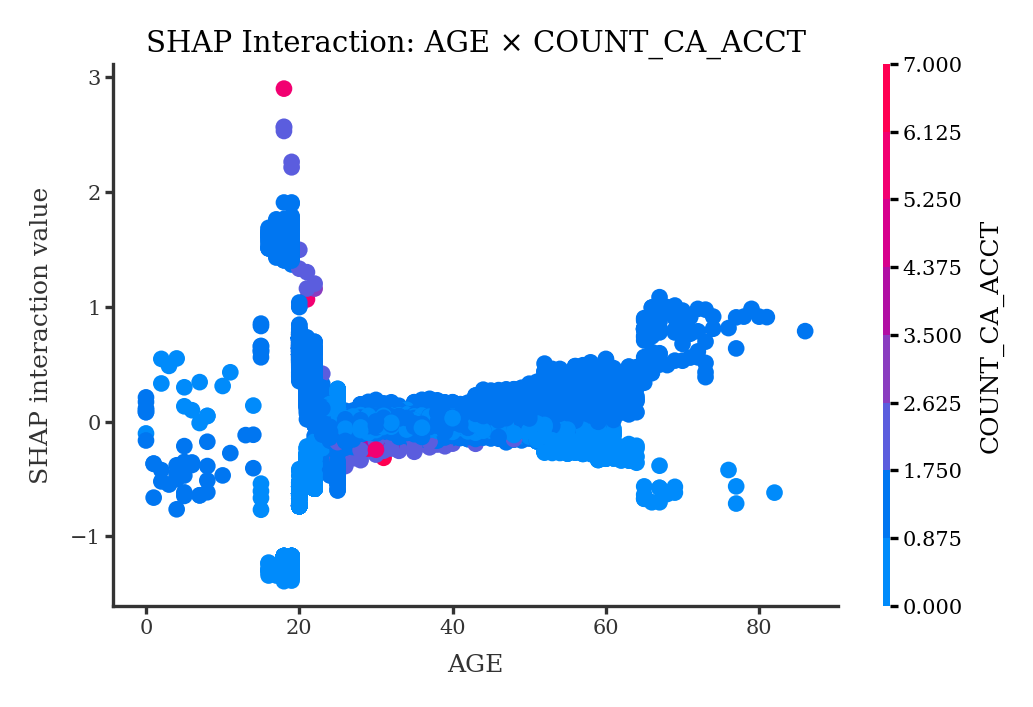

SHAP values and figures saved successfully.


In [ ]:
# ==========================================================
# FULL CODE: XGBOOST + RANDOM OVERSAMPLING + SHAP FIGURES
# IEEE ACCESS SINGLE-COLUMN FORMAT
# ==========================================================

# =========================
# 0. INSTALL IF NEEDED
# =========================
# !pip install shap xgboost imbalanced-learn joblib -q

# =========================
# 1. IMPORT LIBRARIES
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    recall_score,
    f1_score,
    roc_auc_score,
    accuracy_score,
    brier_score_loss
)

from imblearn.over_sampling import RandomOverSampler
from xgboost import XGBClassifier


# ==========================================================
# 2. LOAD DATA
# ==========================================================

df = pd.read_csv("final_dataset_no_auto_job.csv")
df.columns = df.columns.str.strip()

target_col = "COUNT_CREDITCARD"
id_col = "CUSTOMER_NUMBER"

# Binary target: 1 if customer owns at least one credit card
y = (df[target_col] > 0).astype(int)

X = df.drop(columns=[target_col])

if id_col in X.columns:
    X = X.drop(columns=[id_col])

# Encode categorical variables
for col in X.select_dtypes(include=["object", "category"]).columns:
    X[col] = X[col].astype("category").cat.codes


# ==========================================================
# 3. TRAIN / TEST SPLIT
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)


# ==========================================================
# 4. IMPUTATION
#    Fit on train only, transform train and test
# ==========================================================

imputer = SimpleImputer(strategy="median")

X_train_imp = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_imp = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)


# ==========================================================
# 5. RANDOM OVERSAMPLING
#    Apply only on training data
# ==========================================================

ros = RandomOverSampler(random_state=42)

X_train_ros, y_train_ros = ros.fit_resample(
    X_train_imp,
    y_train
)


# ==========================================================
# 6. TRAIN XGBOOST MODEL
# ==========================================================

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train_ros, y_train_ros)


# ==========================================================
# 7. TEST SET EVALUATION
# ==========================================================

y_prob = xgb_model.predict_proba(X_test_imp)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

print("===== XGBoost + Random Oversampling =====")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred):.4f}")
print(f"AUC      : {roc_auc_score(y_test, y_prob):.4f}")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Brier    : {brier_score_loss(y_test, y_prob):.5f}")


# ==========================================================
# 8. SAVE MODEL AND IMPUTER
#    Useful if Colab disconnects
# ==========================================================

joblib.dump(xgb_model, "xgb_ros_model.pkl")
joblib.dump(imputer, "median_imputer.pkl")

print("Model and imputer saved successfully.")


# ==========================================================
# 9. COMPUTE SHAP VALUES
#    Use test set after imputation, not oversampled data
# ==========================================================

X_shap = X_test_imp.copy()

# Optional: reduce sample size if SHAP is slow
# X_shap = X_test_imp.sample(n=5000, random_state=42)

explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_shap)

# For binary classification, some SHAP versions return list
if isinstance(shap_values, list):
    shap_values = shap_values[1]


# ==========================================================
# 10. IEEE FIGURE SETTINGS
# ==========================================================

DPI = 300
FIG_SINGLE = (3.35, 2.20)   # IEEE one-column size

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 6,
    "axes.labelsize": 6,
    "axes.titlesize": 7,
    "xtick.labelsize": 5,
    "ytick.labelsize": 5,
    "legend.fontsize": 5,
    "figure.dpi": DPI,
    "savefig.dpi": DPI
})


def format_shap_figure(title, xlabel=None, ylabel="SHAP value"):
    fig = plt.gcf()
    fig.set_size_inches(FIG_SINGLE)

    ax = plt.gca()

    ax.set_title(title, fontsize=7, pad=3)

    if xlabel is not None:
        ax.set_xlabel(xlabel, fontsize=6)

    ax.set_ylabel(ylabel, fontsize=6)

    ax.tick_params(
        axis="both",
        labelsize=5,
        length=2,
        pad=1
    )

    # Format SHAP colorbar
    for cb_ax in fig.axes:
        if cb_ax is not ax:
            cb_ax.tick_params(labelsize=5, length=2, pad=1)
            cb_ax.yaxis.label.set_size(6)

    plt.tight_layout(pad=0.25)

    return fig, ax


# ==========================================================
# 11. FIG. 9(a): SHAP DEPENDENCE PLOT FOR AGE
#     interaction_index = COUNT_CA_ACCT
# ==========================================================

plt.close("all")

shap.dependence_plot(
    "AGE",
    shap_values,
    X_shap,
    interaction_index="COUNT_CA_ACCT",
    show=False
)

fig, ax = format_shap_figure(
    title="SHAP Dependence Plot for AGE",
    xlabel="AGE",
    ylabel="SHAP value"
)

fig.savefig(
    "Fig_9a_SHAP_Dependence_AGE.png",
    dpi=DPI,
    bbox_inches="tight",
    pad_inches=0.02
)

plt.show()


# ==========================================================
# 12. FIG. 9(b): SHAP DEPENDENCE PLOT FOR AVG_CA_BALANCE
#     interaction_index = COUNT_OF_LOAN
# ==========================================================

plt.close("all")

shap.dependence_plot(
    "AVG_CA_BALANCE",
    shap_values,
    X_shap,
    interaction_index="COUNT_OF_LOAN",
    show=False
)

fig, ax = format_shap_figure(
    title="SHAP Dependence Plot for AVG_CA_BALANCE",
    xlabel="AVG_CA_BALANCE",
    ylabel="SHAP value"
)

fig.savefig(
    "Fig_9b_SHAP_Dependence_AVG_CA_BALANCE.png",
    dpi=DPI,
    bbox_inches="tight",
    pad_inches=0.02
)

plt.show()


# ==========================================================
# 13. FIG. 9(c): SHAP INTERACTION PLOT AGE × COUNT_CA_ACCT
# ==========================================================

plt.close("all")

shap_interaction_values = explainer.shap_interaction_values(X_shap)

if isinstance(shap_interaction_values, list):
    shap_interaction_values = shap_interaction_values[1]

shap.dependence_plot(
    ("AGE", "COUNT_CA_ACCT"),
    shap_interaction_values,
    X_shap,
    show=False
)

fig, ax = format_shap_figure(
    title="SHAP Interaction: AGE × COUNT_CA_ACCT",
    xlabel="AGE",
    ylabel="SHAP interaction value"
)

fig.savefig(
    "Fig_9c_SHAP_Interaction_AGE_COUNT_CA_ACCT.png",
    dpi=DPI,
    bbox_inches="tight",
    pad_inches=0.02
)

plt.show()


# ==========================================================
# 14. OPTIONAL: SAVE SHAP VALUES
# ==========================================================

np.save("shap_values_xgb_ros.npy", shap_values)
X_shap.to_csv("X_shap_test_imp.csv", index=False)

print("SHAP values and figures saved successfully.")

# FULL PIPELINE: TRAIN + ROC + PRECISION@K + CALIBRATION


===== BASIC METRICS =====
Decision threshold: 0.5
AUC: 0.950817
[[18519  3030]
 [  280  3663]]
              precision    recall  f1-score   support

           0     0.9851    0.8594    0.9180     21549
           1     0.5473    0.9290    0.6888      3943

    accuracy                         0.8702     25492
   macro avg     0.7662    0.8942    0.8034     25492
weighted avg     0.9174    0.8702    0.8825     25492



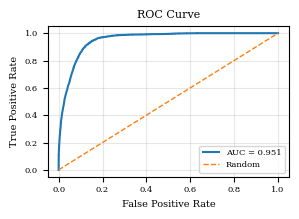


===== PRECISION@TOP-K =====
Top 10% (2549): 0.7815
Top 20% (5098): 0.6314
Top 30% (7647): 0.4967


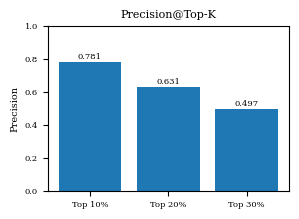


===== CALIBRATION =====
Brier Score: 0.089980


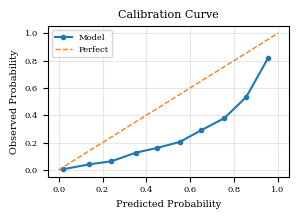


===== SAVED FILES =====
roc.png
precision_at_k.csv
precision_at_k.png
calibration_curve.png


In [ ]:
# =========================
# FULL PIPELINE: TRAIN + ROC + PRECISION@K + CALIBRATION
# PAPER-READY FIGURES FOR 2-COLUMN JOURNAL
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix, roc_curve,
    brier_score_loss
)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.calibration import calibration_curve

from xgboost import XGBClassifier
from imblearn.over_sampling import RandomOverSampler


# =========================
# FIGURE SETTINGS FOR JOURNAL PAPER
# =========================
DPI = 600
FIG_SMALL = (3.0, 2.2)

plt.rcParams.update({
    "font.size": 7,
    "axes.titlesize": 8,
    "axes.labelsize": 7,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 6
})


# =========================
# 1. LOAD DATA
# =========================
df = pd.read_csv("final_dataset_no_auto_job.csv", low_memory=False)
df.columns = df.columns.str.strip()

df = df.replace(
    ["", " ", "NA", "N/A", "na", "null", "NULL", "None", "none"],
    np.nan
)


# =========================
# 2. TARGET
# =========================
target_col = "COUNT_CREDITCARD"
id_col = "CUSTOMER_NUMBER"

df[target_col] = pd.to_numeric(df[target_col], errors="coerce")
df = df.dropna(subset=[target_col]).copy()

df[target_col] = (df[target_col] > 0).astype(int)


# =========================
# 3. FEATURES
# =========================
drop_cols = [c for c in [id_col, target_col] if c in df.columns]
X = df.drop(columns=drop_cols).copy()
y = df[target_col].copy()


# =========================
# 4. TYPE HANDLING
# =========================
for col in X.columns:
    if X[col].dtype == "object":
        converted = pd.to_numeric(X[col], errors="coerce")
        if converted.notna().sum() / max(1, X[col].notna().sum()) >= 0.8:
            X[col] = converted
        else:
            X[col] = X[col].astype("string")

cat_cols = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()


# =========================
# 5. SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


# =========================
# 6. PREPROCESS
# =========================
def preprocess(X_tr, X_te, cat_cols):
    X_tr = X_tr.copy()
    X_te = X_te.copy()

    for col in cat_cols:
        X_tr[col] = X_tr[col].astype("string")
        X_te[col] = X_te[col].astype("string")

    if len(cat_cols) > 0:
        encoder = OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1,
            encoded_missing_value=-1
        )
        X_tr[cat_cols] = encoder.fit_transform(X_tr[cat_cols])
        X_te[cat_cols] = encoder.transform(X_te[cat_cols])

    imputer = SimpleImputer(strategy="median")

    X_tr = pd.DataFrame(
        imputer.fit_transform(X_tr),
        columns=X_tr.columns
    )

    X_te = pd.DataFrame(
        imputer.transform(X_te),
        columns=X_te.columns
    )

    return X_tr, X_te


X_train_prep, X_test_prep = preprocess(X_train, X_test, cat_cols)


# =========================
# 7. RESAMPLE
# =========================
ros = RandomOverSampler(random_state=42)
X_train_res, y_train_res = ros.fit_resample(X_train_prep, y_train)


# =========================
# 8. MODEL
# =========================
model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_res, y_train_res)


# =========================
# 9. PREDICT
# =========================
y_test_prob = model.predict_proba(X_test_prep)[:, 1]

threshold = 0.5
y_test_pred = (y_test_prob >= threshold).astype(int)

auc_value = roc_auc_score(y_test, y_test_prob)

print("\n===== BASIC METRICS =====")
print("Decision threshold:", threshold)
print("AUC:", round(auc_value, 6))
print(confusion_matrix(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred, digits=4))


# =========================
# 10. ROC CURVE
# =========================
fpr, tpr, _ = roc_curve(y_test, y_test_prob)

plt.figure(figsize=FIG_SMALL)

plt.plot(
    fpr,
    tpr,
    linewidth=1.5,
    label=f"AUC = {auc_value:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    "--",
    linewidth=1,
    label="Random"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    "roc.png",
    dpi=DPI,
    bbox_inches="tight",
    pad_inches=0.02
)
plt.show()


# =========================
# 11. PRECISION@TOP-K
# =========================
df_eval = pd.DataFrame({
    "y_true": np.asarray(y_test),
    "y_prob": np.asarray(y_test_prob)
}).sort_values("y_prob", ascending=False).reset_index(drop=True)


def top_precision(df, pct):
    n = max(1, int(len(df) * pct))
    return df.iloc[:n]["y_true"].mean(), n


p10, n10 = top_precision(df_eval, 0.10)
p20, n20 = top_precision(df_eval, 0.20)
p30, n30 = top_precision(df_eval, 0.30)

print("\n===== PRECISION@TOP-K =====")
print(f"Top 10% ({n10}): {p10:.4f}")
print(f"Top 20% ({n20}): {p20:.4f}")
print(f"Top 30% ({n30}): {p30:.4f}")

precision_table = pd.DataFrame({
    "Top (%)": [10, 20, 30],
    "Precision": [p10, p20, p30]
})

precision_table.to_csv("precision_at_k.csv", index=False)


# =========================
# 12. PRECISION@TOP-K FIGURE
# =========================
plt.figure(figsize=FIG_SMALL)

bars = plt.bar(
    ["Top 10%", "Top 20%", "Top 30%"],
    [p10, p20, p30]
)

plt.ylim(0, 1)
plt.ylabel("Precision")
plt.title("Precision@Top-K")

for i, v in enumerate([p10, p20, p30]):
    plt.text(
        i,
        v + 0.02,
        f"{v:.3f}",
        ha="center",
        fontsize=6
    )

plt.tight_layout()
plt.savefig(
    "precision_at_k.png",
    dpi=DPI,
    bbox_inches="tight",
    pad_inches=0.02
)
plt.show()


# =========================
# 13. CALIBRATION (BRIER)
# =========================
brier = brier_score_loss(y_test, y_test_prob)

print("\n===== CALIBRATION =====")
print(f"Brier Score: {brier:.6f}")


# =========================
# 14. CALIBRATION CURVE
# =========================
prob_true, prob_pred = calibration_curve(
    y_test,
    y_test_prob,
    n_bins=10
)

plt.figure(figsize=FIG_SMALL)

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    markersize=3,
    linewidth=1.5,
    label="Model"
)

plt.plot(
    [0, 1],
    [0, 1],
    "--",
    linewidth=1,
    label="Perfect"
)

plt.xlabel("Predicted Probability")
plt.ylabel("Observed Probability")
plt.title("Calibration Curve")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    "calibration_curve.png",
    dpi=DPI,
    bbox_inches="tight",
    pad_inches=0.02
)
plt.show()


print("\n===== SAVED FILES =====")
print("roc.png")
print("precision_at_k.csv")
print("precision_at_k.png")
print("calibration_curve.png")

In [ ]:
import numpy as np

# shuffle label SAU RESAMPLING
y_train_res_shuffle = np.random.permutation(y_train_res)

# train lại
model.fit(X_train_res, y_train_res_shuffle)

# predict
y_test_prob_shuffle = model.predict_proba(X_test_prep)[:, 1]

from sklearn.metrics import roc_auc_score
print("AUC (shuffled):", roc_auc_score(y_test, y_test_prob_shuffle))

AUC (shuffled): 0.46013406010827146


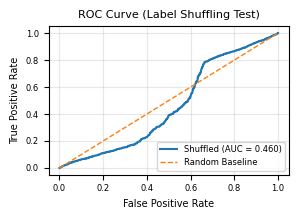

In [ ]:
# =========================
# ROC FOR LABEL SHUFFLING TEST
# =========================

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# sử dụng cùng cấu hình hình của bài báo
DPI = 600
FIG_SMALL = (3.0, 2.2)

plt.rcParams.update({
    "font.size": 7,
    "axes.titlesize": 8,
    "axes.labelsize": 7,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 6
})

fpr_s, tpr_s, _ = roc_curve(y_test, y_test_prob_shuffle)
auc_s = roc_auc_score(y_test, y_test_prob_shuffle)

plt.figure(figsize=FIG_SMALL)

plt.plot(
    fpr_s,
    tpr_s,
    linewidth=1.5,
    label=f"Shuffled (AUC = {auc_s:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    "--",
    linewidth=1,
    label="Random Baseline"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Label Shuffling Test)")

plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "roc_shuffled.png",
    dpi=DPI,
    bbox_inches="tight",
    pad_inches=0.02
)

plt.show()

TRỰC QUAN HÓA CỘT NHÃN

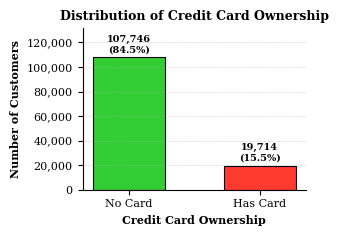

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# ==========================================================
# LOAD DATA
# ==========================================================
df = pd.read_csv("final_dataset_no_auto_job.csv", low_memory=False)
df.columns = df.columns.str.strip()

# ==========================================================
# TARGET COLUMN
# ==========================================================
target = "COUNT_CREDITCARD"

# Chuyển về nhãn nhị phân
df["Credit_Card_Ownership"] = (df[target] > 0).astype(int)

counts = df["Credit_Card_Ownership"].value_counts().sort_index()
percentages = counts / counts.sum() * 100

# ==========================================================
# IEEE STYLE SETTINGS
# ==========================================================
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.labelsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

# ==========================================================
# IEEE SINGLE-COLUMN FIGURE
# ==========================================================
fig, ax = plt.subplots(figsize=(3.2, 2.4))

# Xanh tươi - Đỏ tươi
colors = ["#32CD32", "#FF3B30"]

bars = ax.bar(
    counts.index.astype(str),
    counts.values,
    color=colors,
    edgecolor="black",
    linewidth=0.8,
    width=0.55
)

# ==========================================================
# BAR LABELS
# ==========================================================
y_max = counts.max() * 1.22
ax.set_ylim(0, y_max)

for i, bar in enumerate(bars):
    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + counts.max() * 0.025,
        f"{counts.iloc[i]:,}\n({percentages.iloc[i]:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=7,
        fontweight="bold"
    )

# ==========================================================
# TITLE & AXES
# ==========================================================
ax.set_title(
    "Distribution of Credit Card Ownership",
    fontweight="bold",
    pad=6
)

ax.set_xlabel(
    "Credit Card Ownership",
    fontweight="bold"
)

ax.set_ylabel(
    "Number of Customers",
    fontweight="bold"
)

# ==========================================================
# CUSTOM X LABELS
# ==========================================================
ax.set_xticks([0, 1])
ax.set_xticklabels(["No Card", "Has Card"])

# ==========================================================
# FORMAT Y AXIS
# ==========================================================
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{int(x):,}")
)

# ==========================================================
# CLEAN IEEE STYLE
# ==========================================================
ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.5,
    alpha=0.5
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

# ==========================================================
# SAVE FIGURE
# ==========================================================
plt.savefig(
    "Figure_Class_Distribution_IEEE.png",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    "Figure_Class_Distribution_IEEE.pdf",
    bbox_inches="tight"
)

plt.show()

TẠO BẢNG THỐNG KÊ COUNT_CA_ACCT

In [ ]:
import pandas as pd
import numpy as np

# ==========================================================
# LOAD DATA
# ==========================================================
df = pd.read_csv("final_dataset_no_auto_job.csv", low_memory=False)

# ==========================================================
# CREATE BINARY TARGET
# ==========================================================
df["HAS_CREDITCARD"] = (df["COUNT_CREDITCARD"] > 0).astype(int)

# ==========================================================
# TABLE 1: CREDIT CARD OWNERSHIP RATE BY COUNT_CA_ACCT
# ==========================================================
summary = (
    df.groupby("COUNT_CA_ACCT")
      .agg(
          Customers=("COUNT_CA_ACCT", "size"),
          Card_Holders=("HAS_CREDITCARD", "sum")
      )
      .reset_index()
)

summary["Customer_%"] = (
    summary["Customers"] /
    summary["Customers"].sum() * 100
)

summary["Card_Ownership_Rate_%"] = (
    summary["Card_Holders"] /
    summary["Customers"] * 100
)

summary["Customer_%"] = summary["Customer_%"].round(2)
summary["Card_Ownership_Rate_%"] = summary["Card_Ownership_Rate_%"].round(2)

print("\n" + "="*80)
print("TABLE 1. CREDIT CARD OWNERSHIP RATE BY COUNT_CA_ACCT")
print("="*80)
print(summary)

# ==========================================================
# TABLE 2: PROFILE COMPARISON
# COUNT_CA_ACCT = 0 vs COUNT_CA_ACCT > 0
# ==========================================================
profile = (
    df.assign(
        CA_GROUP=np.where(
            df["COUNT_CA_ACCT"] == 0,
            "COUNT_CA_ACCT = 0",
            "COUNT_CA_ACCT > 0"
        )
    )
    .groupby("CA_GROUP")
    .agg(
        Customers=("CA_GROUP", "size"),
        Credit_Card_Rate=("HAS_CREDITCARD", "mean"),
        Avg_Loan_Count=("COUNT_OF_LOAN", "mean"),
        Avg_Loan_Amount=("AVG_LOAN_AMOUNT", "mean"),
        Avg_Login_Per_Active_Day=("LOGIN_PER_ACTIVE_DAY", "mean"),
        Avg_Age=("AGE", "mean")
    )
)

profile["Credit_Card_Rate"] = (
    profile["Credit_Card_Rate"] * 100
)

profile = profile.round(2)

print("\n" + "="*80)
print("TABLE 2. PROFILE COMPARISON OF CUSTOMERS")
print("="*80)
print(profile)

# ==========================================================
# SAVE RESULTS
# ==========================================================
summary.to_csv(
    "count_ca_acct_summary.csv",
    index=False
)

profile.to_csv(
    "count_ca_acct_profile.csv"
)

print("\nFiles saved:")
print(" - count_ca_acct_summary.csv")
print(" - count_ca_acct_profile.csv")


TABLE 1. CREDIT CARD OWNERSHIP RATE BY COUNT_CA_ACCT
   COUNT_CA_ACCT  Customers  Card_Holders  Customer_%  Card_Ownership_Rate_%
0              0      35573         16147       27.91                  45.39
1              1      91366          3543       71.68                   3.88
2              2        447            24        0.35                   5.37
3              3         21             0        0.02                   0.00
4              4          7             0        0.01                   0.00
5              5          4             0        0.00                   0.00
6              6         17             0        0.01                   0.00
7              7         23             0        0.02                   0.00
8              8          1             0        0.00                   0.00
9             10          1             0        0.00                   0.00

TABLE 2. PROFILE COMPARISON OF CUSTOMERS
                   Customers  Credit_Card_Rate  Avg_Loan_

E2 Ablation: bỏ COUNT_CA_ACCT

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, recall_score, f1_score, accuracy_score, roc_curve
from sklearn.impute import SimpleImputer
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler
from xgboost import XGBClassifier

# =========================
# METRICS
# =========================
def ks_score(y_true, y_prob):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    return np.max(tpr - fpr)

def ranking_metrics(y_true, y_prob):
    df = pd.DataFrame({"y": y_true, "prob": y_prob})
    df = df.sort_values("prob", ascending=False).reset_index(drop=True)

    base_rate = df["y"].mean()
    n = len(df)

    top10 = df.iloc[:int(0.10 * n)]
    p10 = top10["y"].mean()
    capture10 = top10["y"].sum() / df["y"].sum()

    d1 = top10["y"].mean()
    lift_d1 = d1 / base_rate

    return p10, capture10, lift_d1

def run_xgb_ros(data_path, remove_feature=None):
    df = pd.read_csv(data_path)
    df.columns = df.columns.str.strip()

    y = (df["COUNT_CREDITCARD"] > 0).astype(int)
    X = df.drop(columns=["COUNT_CREDITCARD", "CUSTOMER_NUMBER"], errors="ignore")

    if remove_feature is not None:
        X = X.drop(columns=[remove_feature], errors="ignore")

    # Encode categorical variables
    for col in X.select_dtypes(include="object").columns:
        X[col] = X[col].astype("category").cat.codes

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("ros", RandomOverSampler(random_state=42)),
        ("xgb", XGBClassifier(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        ))
    ])

    model.fit(X_train, y_train)

    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    p10, capture10, lift_d1 = ranking_metrics(y_test.values, y_prob)

    return {
        "Removed Feature": remove_feature if remove_feature else "None",
        "AUC": roc_auc_score(y_test, y_prob),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "Accuracy": accuracy_score(y_test, y_pred),
        "KS": ks_score(y_test, y_prob),
        "Precision@10%": p10,
        "Capture@10%": capture10,
        "Lift@D1": lift_d1
    }

# =========================
# RUN E2
# =========================
data_path = "final_dataset_no_auto_job.csv"

full_result = run_xgb_ros(data_path)
ablation_result = run_xgb_ros(data_path, remove_feature="COUNT_CA_ACCT")

results = pd.DataFrame([full_result, ablation_result])
print(results)

results.to_csv("E2_COUNT_CA_ACCT_ablation_results.csv", index=False)

/tmp/ipykernel_1114/1796504300.py:35: DtypeWarning: Columns (2,3,4,9,10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_path)
/tmp/ipykernel_1114/1796504300.py:35: DtypeWarning: Columns (2,3,4,9,10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_path)


  Removed Feature       AUC    Recall        F1  Accuracy        KS  \
0            None  0.950974  0.926959  0.688518  0.870273  0.789996   
1   COUNT_CA_ACCT  0.950623  0.928227  0.688488  0.870077  0.790007   

   Precision@10%  Capture@10%   Lift@D1  
0       0.779129     0.503677  5.037169  
1       0.781091     0.504945  5.049851  


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    recall_score,
    f1_score,
    accuracy_score,
    roc_curve
)
from sklearn.impute import SimpleImputer

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler

from xgboost import XGBClassifier


# =========================
# CONFIG
# =========================
data_path = "final_dataset_no_auto_job.csv"

target_col = "COUNT_CREDITCARD"
id_col = "CUSTOMER_NUMBER"

account_features = [
    "COUNT_CA_ACCT",
    "AVG_CA_BALANCE",
    "COUNT_TD_ACCT",
    "AVG_TD_BALANCE"
]


# =========================
# METRICS
# =========================
def ks_score(y_true, y_prob):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    return np.max(tpr - fpr)


def ranking_metrics(y_true, y_prob):
    df_rank = pd.DataFrame({
        "y": np.asarray(y_true),
        "prob": np.asarray(y_prob)
    })

    df_rank = df_rank.sort_values(
        "prob",
        ascending=False
    ).reset_index(drop=True)

    base_rate = df_rank["y"].mean()
    total_positive = df_rank["y"].sum()
    n = len(df_rank)

    top10_n = int(np.ceil(0.10 * n))
    top10 = df_rank.iloc[:top10_n]

    precision_10 = top10["y"].mean()
    capture_10 = top10["y"].sum() / total_positive
    lift_d1 = precision_10 / base_rate

    return precision_10, capture_10, lift_d1


# =========================
# RUN ONE EXPERIMENT
# =========================
def run_xgb_ros(data_path, feature_set_name, remove_features=None):
    df = pd.read_csv(data_path)
    df.columns = df.columns.str.strip()

    y = (df[target_col] > 0).astype(int)

    X = df.drop(
        columns=[target_col, id_col],
        errors="ignore"
    ).copy()

    if remove_features is None:
        remove_features = []

    missing_features = [
        col for col in remove_features
        if col not in X.columns
    ]

    if missing_features:
        print(f"Warning: features not found and ignored: {missing_features}")

    X = X.drop(
        columns=remove_features,
        errors="ignore"
    )

    print("=" * 70)
    print("Experiment:", feature_set_name)
    print("Removed features:", remove_features if remove_features else "None")
    print("Number of features used:", X.shape[1])
    print("COUNT_CA_ACCT in X:", "COUNT_CA_ACCT" in X.columns)
    print("=" * 70)

    # Encode categorical variables
    for col in X.select_dtypes(include="object").columns:
        X[col] = X[col].astype("category").cat.codes

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("ros", RandomOverSampler(random_state=42)),
        ("xgb", XGBClassifier(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        ))
    ])

    model.fit(X_train, y_train)

    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    precision_10, capture_10, lift_d1 = ranking_metrics(
        y_test.values,
        y_prob
    )

    return {
        "Feature Set": feature_set_name,
        "No. Features": X.shape[1],
        "AUC": roc_auc_score(y_test, y_prob),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "Accuracy": accuracy_score(y_test, y_pred),
        "KS": ks_score(y_test, y_prob),
        "Precision@10%": precision_10,
        "Capture@10%": capture_10,
        "Lift@D1": lift_d1
    }


# =========================
# RUN E2 ABLATION
# =========================
results = []

results.append(
    run_xgb_ros(
        data_path=data_path,
        feature_set_name="Full Model",
        remove_features=None
    )
)

results.append(
    run_xgb_ros(
        data_path=data_path,
        feature_set_name="Without COUNT_CA_ACCT",
        remove_features=["COUNT_CA_ACCT"]
    )
)

results.append(
    run_xgb_ros(
        data_path=data_path,
        feature_set_name="Without Account Features",
        remove_features=account_features
    )
)

results_df = pd.DataFrame(results)

metric_cols = [
    "AUC",
    "Recall",
    "F1",
    "Accuracy",
    "KS",
    "Precision@10%",
    "Capture@10%",
    "Lift@D1"
]

results_df[metric_cols] = results_df[metric_cols].round(6)

print("\nE2 Ablation Results:")
print(results_df)

results_df.to_csv(
    "E2_Ablation_Results.csv",
    index=False
)

print("\nSaved file: E2_Ablation_Results.csv")

/tmp/ipykernel_1114/1597733348.py:73: DtypeWarning: Columns (2,3,4,9,10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_path)


Experiment: Full Model
Removed features: None
Number of features used: 20
COUNT_CA_ACCT in X: True


/tmp/ipykernel_1114/1597733348.py:73: DtypeWarning: Columns (2,3,4,9,10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_path)


Experiment: Without COUNT_CA_ACCT
Removed features: ['COUNT_CA_ACCT']
Number of features used: 19
COUNT_CA_ACCT in X: False


/tmp/ipykernel_1114/1597733348.py:73: DtypeWarning: Columns (2,3,4,9,10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_path)


Experiment: Without Account Features
Removed features: ['COUNT_CA_ACCT', 'AVG_CA_BALANCE', 'COUNT_TD_ACCT', 'AVG_TD_BALANCE']
Number of features used: 16
COUNT_CA_ACCT in X: False

E2 Ablation Results:
                Feature Set  No. Features       AUC    Recall        F1  \
0                Full Model            20  0.950974  0.926959  0.688518   
1     Without COUNT_CA_ACCT            19  0.950623  0.928227  0.688488   
2  Without Account Features            16  0.859507  0.819173  0.486482   

   Accuracy        KS  Precision@10%  Capture@10%   Lift@D1  
0  0.870273  0.789996       0.779216     0.503931  5.037729  
1  0.870077  0.790007       0.780784     0.504945  5.047871  
2  0.732504  0.539768       0.622353     0.402485  4.023591  

Saved file: E2_Ablation_Results.csv


FAIRNESS

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import (
    roc_auc_score,
    brier_score_loss,
    recall_score,
    f1_score,
    accuracy_score
)

from imblearn.over_sampling import RandomOverSampler
from xgboost import XGBClassifier

# =========================
# 1. LOAD DATA
# =========================
df = pd.read_csv("final_dataset_no_auto_job.csv", low_memory=False)
df.columns = df.columns.str.strip()

df = df.replace(
    ["", " ", "NA", "N/A", "na", "null", "NULL", "None", "none"],
    np.nan
)

# =========================
# 2. TARGET
# =========================
target_col = "COUNT_CREDITCARD"
id_col = "CUSTOMER_NUMBER"
sex_col = "CLIENT_SEX"
age_col = "AGE"

df[target_col] = pd.to_numeric(df[target_col], errors="coerce")
df = df.dropna(subset=[target_col]).copy()

# Tạo nhãn nhị phân
df[target_col] = (df[target_col] > 0).astype(int)

# =========================
# 3. FEATURES
# =========================
drop_cols = [id_col, target_col]
X = df.drop(columns=drop_cols).copy()
y = df[target_col].copy()

# =========================
# 4. HARMONIZE COLUMN TYPES
# =========================
for col in X.columns:
    if X[col].dtype == "object":
        converted = pd.to_numeric(X[col], errors="coerce")
        non_null_original = X[col].notna().sum()
        non_null_converted = converted.notna().sum()

        if non_null_original > 0 and (non_null_converted / non_null_original) >= 0.8:
            X[col] = converted
        else:
            X[col] = X[col].astype("string")

cat_cols = X.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

num_cols = [c for c in X.columns if c not in cat_cols]

print("Categorical columns:", cat_cols)
print("Numerical columns:", num_cols)
print("Dataset shape:", df.shape)
print("Target distribution:")
print(y.value_counts(normalize=True))

# =========================
# 5. TRAIN / TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# =========================
# 6. PREPROCESS FUNCTION
# =========================
def fit_preprocess(X_tr, X_val, cat_cols):
    X_tr = X_tr.copy()
    X_val = X_val.copy()

    for col in cat_cols:
        X_tr[col] = X_tr[col].astype("string")
        X_val[col] = X_val[col].astype("string")

    if len(cat_cols) > 0:
        encoder = OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1,
            encoded_missing_value=-1
        )

        X_tr[cat_cols] = encoder.fit_transform(X_tr[cat_cols])
        X_val[cat_cols] = encoder.transform(X_val[cat_cols])
    else:
        encoder = None

    imputer = SimpleImputer(strategy="median")

    X_tr = pd.DataFrame(
        imputer.fit_transform(X_tr),
        columns=X_tr.columns,
        index=X_tr.index
    )

    X_val = pd.DataFrame(
        imputer.transform(X_val),
        columns=X_val.columns,
        index=X_val.index
    )

    return X_tr, X_val, imputer, encoder

# =========================
# 7. PREPROCESS TRAIN / TEST
# =========================
X_train_prep, X_test_prep, final_imputer, final_encoder = fit_preprocess(
    X_train,
    X_test,
    cat_cols
)

# =========================
# 8. RANDOM OVERSAMPLING ONLY TRAIN
# =========================
ros = RandomOverSampler(random_state=42)

X_train_res, y_train_res = ros.fit_resample(
    X_train_prep,
    y_train
)

# =========================
# 9. TRAIN XGBOOST + ROS
# =========================
final_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_train_res, y_train_res)

# =========================
# 10. TEST PREDICTION
# =========================
y_test_prob = final_model.predict_proba(X_test_prep)[:, 1]
y_test_pred = (y_test_prob >= 0.5).astype(int)

print("\n===== TEST RESULTS: XGBOOST + ROS =====")
print("AUC      :", roc_auc_score(y_test, y_test_prob))
print("Recall   :", recall_score(y_test, y_test_pred))
print("F1-score :", f1_score(y_test, y_test_pred))
print("Accuracy :", accuracy_score(y_test, y_test_pred))

# =========================
# 11. CREATE FAIRNESS TEST DATA
# =========================
fair_df = X_test.copy()
fair_df["y_true"] = y_test.values
fair_df["y_prob"] = y_test_prob

fair_df[age_col] = pd.to_numeric(fair_df[age_col], errors="coerce")

# Giới tính
fair_df["SEX_GROUP"] = fair_df[sex_col].astype(str)

# Nhóm tuổi
fair_df["AGE_GROUP"] = pd.cut(
    fair_df[age_col],
    bins=[0, 30, 45, 60, np.inf],
    labels=["Age<30", "30–45", "46–60", ">60"],
    right=False
)

# =========================
# 12. GROUP-WISE PERFORMANCE FUNCTION
# =========================
def group_performance(data, group_col, top_rate=0.20):
    rows = []

    for group_name, g in data.groupby(group_col, observed=False):
        g = g.copy()

        n = len(g)
        positives = g["y_true"].sum()

        base_rate = g["y_true"].mean()

        auc = (
            roc_auc_score(g["y_true"], g["y_prob"])
            if g["y_true"].nunique() == 2
            else np.nan
        )

        brier = brier_score_loss(g["y_true"], g["y_prob"])

        k = max(1, int(np.ceil(n * top_rate)))
        top_g = g.sort_values("y_prob", ascending=False).head(k)

        tpr_top20 = (
            top_g["y_true"].sum() / positives
            if positives > 0
            else np.nan
        )

        selection_rate = len(top_g) / n

        rows.append({
            "Group": group_name,
            "n": n,
            "Base rate": base_rate,
            "AUC": auc,
            "Brier": brier,
            "TPR@top-20%": tpr_top20,
            "Selection rate@top-20%": selection_rate
        })

    return pd.DataFrame(rows)

# =========================
# 13. TABLE 11
# =========================
sex_perf = group_performance(fair_df, "SEX_GROUP")
age_perf = group_performance(fair_df, "AGE_GROUP")

table11 = pd.concat(
    [sex_perf, age_perf],
    ignore_index=True
)

table11_fmt = table11.copy()

for col in [
    "Base rate",
    "AUC",
    "Brier",
    "TPR@top-20%",
    "Selection rate@top-20%"
]:
    table11_fmt[col] = table11_fmt[col].map(
        lambda x: "" if pd.isna(x) else f"{x:.3f}"
    )

# =========================
# 14. TABLE 12
# =========================
def fairness_summary(perf_df, comparison_name):
    return {
        "Comparison": comparison_name,
        "DI ratio": (
            perf_df["Selection rate@top-20%"].min()
            / perf_df["Selection rate@top-20%"].max()
        ),
        "ΔTPR (Equal Opp.)": (
            perf_df["TPR@top-20%"].max()
            - perf_df["TPR@top-20%"].min()
        ),
        "ΔAUC": (
            perf_df["AUC"].max()
            - perf_df["AUC"].min()
        )
    }

table12 = pd.DataFrame([
    fairness_summary(sex_perf, "Sex"),
    fairness_summary(age_perf, "Age (max–min pair)")
])

table12_fmt = table12.copy()

for col in ["DI ratio", "ΔTPR (Equal Opp.)", "ΔAUC"]:
    table12_fmt[col] = table12_fmt[col].map(
        lambda x: "" if pd.isna(x) else f"{x:.3f}"
    )

# =========================
# 15. PRINT TABLES
# =========================
print("\nTABLE 11. Group-wise performance of the selected model (VIB test set)")
print(table11_fmt)

print("\nTABLE 12. Fairness summary metrics")
print(table12_fmt)

# =========================
# 16. EXPORT FILE
# =========================
with pd.ExcelWriter("fairness_tables_xgboost_ros.xlsx") as writer:
    table11_fmt.to_excel(writer, sheet_name="Table 11", index=False)
    table12_fmt.to_excel(writer, sheet_name="Table 12", index=False)
    fair_df.to_excel(writer, sheet_name="Fairness test data", index=False)

table11_fmt.to_csv("table11_groupwise_performance.csv", index=False)
table12_fmt.to_csv("table12_fairness_summary.csv", index=False)

print("\nĐã xuất:")
print("fairness_tables_xgboost_ros.xlsx")
print("table11_groupwise_performance.csv")
print("table12_fairness_summary.csv")

Categorical columns: ['CLIENT_SEX', 'EB_REGISTER_CHANNEL', 'SMS', 'VERIFY_METHOD', 'TRANS_LV1_MODE', 'TRANS_LV2_MODE']
Numerical columns: ['AGE', 'LOGIN_PER_ACTIVE_DAY', 'INTEREST_RATE_RATIO', 'TRANS_AMOUNT_MAX', 'TRANS_AMOUNT_MEAN', 'TRANS_LV1_MODE_CODE', 'TRANS_LV2_MODE_CODE', 'COUNT_CA_ACCT', 'AVG_CA_BALANCE', 'COUNT_TD_ACCT', 'AVG_TD_BALANCE', 'COUNT_OF_LOAN', 'AVG_LOAN_AMOUNT', 'TOTAL_LOAN_AMOUNT']
Dataset shape: (127460, 22)
Target distribution:
COUNT_CREDITCARD
0    0.845332
1    0.154668
Name: proportion, dtype: float64

===== TEST RESULTS: XGBOOST + ROS =====
AUC      : 0.9510342029119369
Recall   : 0.9297489221405022
F1-score : 0.692155196828094
Accuracy : 0.8720775145143574

TABLE 11. Group-wise performance of the selected model (VIB test set)
    Group      n Base rate    AUC  Brier TPR@top-20% Selection rate@top-20%
0       0      4     1.000         0.000       0.250                  0.250
1       F  10905     0.155  0.950  0.091       0.816                  0.200
2      

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import (
    roc_auc_score,
    brier_score_loss,
    recall_score,
    f1_score,
    accuracy_score
)

from imblearn.over_sampling import RandomOverSampler
from xgboost import XGBClassifier

# =========================
# 1. LOAD DATA
# =========================
df = pd.read_csv("final_dataset_no_auto_job.csv", low_memory=False)
df.columns = df.columns.str.strip()

df = df.replace(
    ["", " ", "NA", "N/A", "na", "null", "NULL", "None", "none"],
    np.nan
)

# =========================
# 2. DEFINE COLUMNS
# =========================
target_col = "COUNT_CREDITCARD"
id_col = "CUSTOMER_NUMBER"
sex_col = "CLIENT_SEX"
age_col = "AGE"

# =========================
# 3. TARGET
# =========================
df[target_col] = pd.to_numeric(df[target_col], errors="coerce")
df = df.dropna(subset=[target_col]).copy()
df[target_col] = (df[target_col] > 0).astype(int)

# =========================
# 4. FEATURES
# =========================
drop_cols = [id_col, target_col]
X = df.drop(columns=drop_cols).copy()
y = df[target_col].copy()

# =========================
# 5. HARMONIZE COLUMN TYPES
# =========================
for col in X.columns:
    if X[col].dtype == "object":
        converted = pd.to_numeric(X[col], errors="coerce")
        non_null_original = X[col].notna().sum()
        non_null_converted = converted.notna().sum()

        if non_null_original > 0 and (non_null_converted / non_null_original) >= 0.8:
            X[col] = converted
        else:
            X[col] = X[col].astype("string")

cat_cols = X.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

# =========================
# 6. TRAIN / TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# =========================
# 7. PREPROCESS FUNCTION
# =========================
def fit_preprocess(X_tr, X_val, cat_cols):
    X_tr = X_tr.copy()
    X_val = X_val.copy()

    for col in cat_cols:
        X_tr[col] = X_tr[col].astype("string")
        X_val[col] = X_val[col].astype("string")

    if len(cat_cols) > 0:
        encoder = OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1,
            encoded_missing_value=-1
        )
        X_tr[cat_cols] = encoder.fit_transform(X_tr[cat_cols])
        X_val[cat_cols] = encoder.transform(X_val[cat_cols])
    else:
        encoder = None

    imputer = SimpleImputer(strategy="median")

    X_tr = pd.DataFrame(
        imputer.fit_transform(X_tr),
        columns=X_tr.columns,
        index=X_tr.index
    )

    X_val = pd.DataFrame(
        imputer.transform(X_val),
        columns=X_val.columns,
        index=X_val.index
    )

    return X_tr, X_val, imputer, encoder

# =========================
# 8. PREPROCESS
# =========================
X_train_prep, X_test_prep, final_imputer, final_encoder = fit_preprocess(
    X_train,
    X_test,
    cat_cols
)

# =========================
# 9. RANDOM OVERSAMPLING ONLY TRAIN
# =========================
ros = RandomOverSampler(random_state=42)

X_train_res, y_train_res = ros.fit_resample(
    X_train_prep,
    y_train
)

# =========================
# 10. TRAIN XGBOOST + ROS
# =========================
final_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_train_res, y_train_res)

# =========================
# 11. TEST PREDICTION
# =========================
threshold = 0.5

y_test_prob = final_model.predict_proba(X_test_prep)[:, 1]
y_test_pred = (y_test_prob >= threshold).astype(int)

print("\n===== TEST RESULTS: XGBOOST + ROS =====")
print("AUC      :", roc_auc_score(y_test, y_test_prob))
print("Recall   :", recall_score(y_test, y_test_pred))
print("F1-score :", f1_score(y_test, y_test_pred))
print("Accuracy :", accuracy_score(y_test, y_test_pred))

# =========================
# 12. FAIRNESS TEST DATA
# =========================
fair_df = X_test.copy()
fair_df["y_true"] = y_test.values
fair_df["y_prob"] = y_test_prob
fair_df["y_pred"] = y_test_pred

fair_df[age_col] = pd.to_numeric(fair_df[age_col], errors="coerce")

# =========================
# 13. CLEAN SEX GROUP
# =========================
fair_df[sex_col] = (
    fair_df[sex_col]
    .replace({
        0: np.nan,
        "0": np.nan,
        "Male": "M",
        "Female": "F",
        "male": "M",
        "female": "F"
    })
)

sex_fair_df = fair_df[fair_df[sex_col].isin(["M", "F"])].copy()
sex_fair_df["SEX_GROUP"] = sex_fair_df[sex_col]

# =========================
# 14. AGE GROUP: <30, 30–45, ≥46
# =========================
age_fair_df = fair_df.dropna(subset=[age_col]).copy()

age_fair_df["AGE_GROUP"] = pd.cut(
    age_fair_df[age_col],
    bins=[0, 30, 45, 200],
    labels=["<30", "30–45", "≥46"],
    right=False
)

age_fair_df = age_fair_df.dropna(subset=["AGE_GROUP"]).copy()

# =========================
# 15. GROUP PERFORMANCE FUNCTION
# =========================
def group_performance(data, group_col, top_rate=0.20):
    rows = []

    for group_name, g in data.groupby(group_col, observed=False):
        g = g.copy()

        n = len(g)
        positives = g["y_true"].sum()
        base_rate = g["y_true"].mean()

        auc = (
            roc_auc_score(g["y_true"], g["y_prob"])
            if g["y_true"].nunique() == 2
            else np.nan
        )

        brier = brier_score_loss(g["y_true"], g["y_prob"])

        selection_rate_threshold = g["y_pred"].mean()

        tpr_threshold = (
            ((g["y_true"] == 1) & (g["y_pred"] == 1)).sum() / positives
            if positives > 0
            else np.nan
        )

        # Ranking metric: Top 20% within each group
        k = max(1, int(np.ceil(n * top_rate)))
        top_g = g.sort_values("y_prob", ascending=False).head(k)

        tpr_top20 = (
            top_g["y_true"].sum() / positives
            if positives > 0
            else np.nan
        )

        rows.append({
            "Group": group_name,
            "n": n,
            "Base rate": base_rate,
            "AUC": auc,
            "Brier": brier,
            "TPR@threshold": tpr_threshold,
            "Selection rate@threshold": selection_rate_threshold,
            "TPR@top-20%": tpr_top20
        })

    return pd.DataFrame(rows)

# =========================
# 16. TABLE 11
# =========================
sex_perf = group_performance(sex_fair_df, "SEX_GROUP")
age_perf = group_performance(age_fair_df, "AGE_GROUP")

table11 = pd.concat(
    [sex_perf, age_perf],
    ignore_index=True
)

table11_fmt = table11.copy()

for col in [
    "Base rate",
    "AUC",
    "Brier",
    "TPR@threshold",
    "Selection rate@threshold",
    "TPR@top-20%"
]:
    table11_fmt[col] = table11_fmt[col].map(
        lambda x: "" if pd.isna(x) else f"{x:.3f}"
    )

# =========================
# 17. TABLE 12
# =========================
def fairness_summary(perf_df, comparison_name):
    return {
        "Comparison": comparison_name,
        "DI ratio": (
            perf_df["Selection rate@threshold"].min()
            / perf_df["Selection rate@threshold"].max()
        ),
        "ΔTPR (Equal Opp.)": (
            perf_df["TPR@threshold"].max()
            - perf_df["TPR@threshold"].min()
        ),
        "ΔAUC": (
            perf_df["AUC"].max()
            - perf_df["AUC"].min()
        )
    }

table12 = pd.DataFrame([
    fairness_summary(sex_perf, "Sex"),
    fairness_summary(age_perf, "Age (<30 / 30–45 / ≥46)")
])

table12_fmt = table12.copy()

for col in ["DI ratio", "ΔTPR (Equal Opp.)", "ΔAUC"]:
    table12_fmt[col] = table12_fmt[col].map(
        lambda x: "" if pd.isna(x) else f"{x:.3f}"
    )

# =========================
# 18. PRINT TABLES
# =========================
print("\nTABLE 11. Group-wise performance of the selected model (VIB test set)")
print(table11_fmt)

print("\nTABLE 12. Fairness summary metrics")
print(table12_fmt)

# =========================
# 19. EXPORT
# =========================
with pd.ExcelWriter("fairness_tables_xgboost_ros_cleaned.xlsx") as writer:
    table11_fmt.to_excel(writer, sheet_name="Table 11", index=False)
    table12_fmt.to_excel(writer, sheet_name="Table 12", index=False)
    sex_fair_df.to_excel(writer, sheet_name="Sex fairness data", index=False)
    age_fair_df.to_excel(writer, sheet_name="Age fairness data", index=False)

table11_fmt.to_csv("table11_groupwise_performance_cleaned.csv", index=False)
table12_fmt.to_csv("table12_fairness_summary_cleaned.csv", index=False)

print("\nĐã xuất:")
print("fairness_tables_xgboost_ros_cleaned.xlsx")
print("table11_groupwise_performance_cleaned.csv")
print("table12_fairness_summary_cleaned.csv")


===== TEST RESULTS: XGBOOST + ROS =====
AUC      : 0.9510342029119369
Recall   : 0.9297489221405022
F1-score : 0.692155196828094
Accuracy : 0.8720775145143574

TABLE 11. Group-wise performance of the selected model (VIB test set)
   Group      n Base rate    AUC  Brier TPR@threshold  \
0      F  10905     0.155  0.950  0.091         0.930   
1      M  14583     0.154  0.951  0.089         0.929   
2    <30  15159     0.093  0.962  0.063         0.904   
3  30–45   8107     0.266  0.927  0.132         0.952   
4    ≥46   2226     0.168  0.925  0.115         0.896   

  Selection rate@threshold TPR@top-20%  
0                    0.260       0.816  
1                    0.261       0.818  
2                    0.168       0.948  
3                    0.420       0.587  
4                    0.317       0.715  

TABLE 12. Fairness summary metrics
                Comparison DI ratio ΔTPR (Equal Opp.)   ΔAUC
0                      Sex    0.998             0.001  0.001
1  Age (<30 / 30–45 / 

LOẠI BỎ AGE. SEX

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import (
    roc_auc_score, recall_score, f1_score,
    accuracy_score, brier_score_loss, roc_curve
)

from imblearn.over_sampling import RandomOverSampler
from xgboost import XGBClassifier


# =========================
# 1. LOAD DATA
# =========================
df = pd.read_csv("final_dataset_no_auto_job.csv", low_memory=False)
df.columns = df.columns.str.strip()

df = df.replace(
    ["", " ", "NA", "N/A", "na", "null", "NULL", "None", "none"],
    np.nan
)

target_col = "COUNT_CREDITCARD"
id_col = "CUSTOMER_NUMBER"

df[target_col] = pd.to_numeric(df[target_col], errors="coerce")
df = df.dropna(subset=[target_col]).copy()
df[target_col] = (df[target_col] > 0).astype(int)

y = df[target_col].copy()


# =========================
# 2. COMMON TRAIN TEST SPLIT
# =========================
all_features = df.drop(columns=[id_col, target_col]).copy()

X_train_base, X_test_base, y_train, y_test = train_test_split(
    all_features,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


# =========================
# 3. PREPROCESS FUNCTION
# =========================
def harmonize_types(X_train, X_test):
    X_train = X_train.copy()
    X_test = X_test.copy()

    for col in X_train.columns:
        if X_train[col].dtype == "object":
            converted_train = pd.to_numeric(X_train[col], errors="coerce")
            non_null_original = X_train[col].notna().sum()
            non_null_converted = converted_train.notna().sum()

            if non_null_original > 0 and (non_null_converted / non_null_original) >= 0.8:
                X_train[col] = converted_train
                X_test[col] = pd.to_numeric(X_test[col], errors="coerce")
            else:
                X_train[col] = X_train[col].astype("string")
                X_test[col] = X_test[col].astype("string")

    return X_train, X_test


def fit_preprocess(X_train, X_test):
    X_train, X_test = harmonize_types(X_train, X_test)

    cat_cols = X_train.select_dtypes(
        include=["object", "string", "category"]
    ).columns.tolist()

    for col in cat_cols:
        X_train[col] = X_train[col].astype("string")
        X_test[col] = X_test[col].astype("string")

    if len(cat_cols) > 0:
        encoder = OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1,
            encoded_missing_value=-1
        )

        X_train[cat_cols] = encoder.fit_transform(X_train[cat_cols])
        X_test[cat_cols] = encoder.transform(X_test[cat_cols])

    imputer = SimpleImputer(strategy="median")

    X_train_prep = pd.DataFrame(
        imputer.fit_transform(X_train),
        columns=X_train.columns,
        index=X_train.index
    )

    X_test_prep = pd.DataFrame(
        imputer.transform(X_test),
        columns=X_test.columns,
        index=X_test.index
    )

    return X_train_prep, X_test_prep


# =========================
# 4. MODEL FUNCTION
# =========================
def get_xgb_model():
    return XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )


# =========================
# 5. METRIC FUNCTIONS
# =========================
def ks_statistic(y_true, y_prob):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    return np.max(tpr - fpr)


def precision_lift_at_k(y_true, y_prob, rates=[0.10, 0.20, 0.30]):
    result = pd.DataFrame({
        "y_true": np.asarray(y_true),
        "y_prob": np.asarray(y_prob)
    }).sort_values("y_prob", ascending=False).reset_index(drop=True)

    overall_rate = result["y_true"].mean()
    n = len(result)

    metrics = {}

    for rate in rates:
        k = int(np.ceil(n * rate))
        top_df = result.iloc[:k]

        precision = top_df["y_true"].mean()
        lift = precision / overall_rate

        metrics[f"Precision@{int(rate*100)}%"] = precision
        metrics[f"Lift@{int(rate*100)}%"] = lift

    return metrics


def evaluate_model(setting_name, X_train, X_test, y_train, y_test):
    # Preprocess
    X_train_prep, X_test_prep = fit_preprocess(X_train, X_test)

    # ROS only on train
    ros = RandomOverSampler(random_state=42)
    X_train_res, y_train_res = ros.fit_resample(X_train_prep, y_train)

    # Train
    model = get_xgb_model()
    model.fit(X_train_res, y_train_res)

    # Predict
    y_prob = model.predict_proba(X_test_prep)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    # Metrics
    ranking_metrics = precision_lift_at_k(y_test, y_prob)

    row = {
        "Setting": setting_name,
        "No. Features": X_train.shape[1],
        "AUC": roc_auc_score(y_test, y_prob),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "Accuracy": accuracy_score(y_test, y_pred),
        "Brier": brier_score_loss(y_test, y_prob),
        "KS": ks_statistic(y_test, y_prob),
        "Precision@10%": ranking_metrics["Precision@10%"],
        "Precision@20%": ranking_metrics["Precision@20%"],
        "Precision@30%": ranking_metrics["Precision@30%"],
        "Lift@D1": ranking_metrics["Lift@10%"],
        "Lift@20%": ranking_metrics["Lift@20%"],
        "Lift@30%": ranking_metrics["Lift@30%"]
    }

    return row


# =========================
# 6. RUN ABLATION SETTINGS
# =========================
settings = {
    "Full model": [],
    "Without CLIENT_SEX": ["CLIENT_SEX"],
    "Without AGE": ["AGE"],
    "Without AGE + CLIENT_SEX": ["AGE", "CLIENT_SEX"]
}

rows = []

for setting_name, drop_features in settings.items():
    print(f"\nRunning: {setting_name}")

    X_train = X_train_base.drop(
        columns=[c for c in drop_features if c in X_train_base.columns]
    ).copy()

    X_test = X_test_base.drop(
        columns=[c for c in drop_features if c in X_test_base.columns]
    ).copy()

    row = evaluate_model(
        setting_name,
        X_train,
        X_test,
        y_train,
        y_test
    )

    rows.append(row)

    print(row)


# =========================
# 7. CREATE RESULT TABLE
# =========================
ablation_results = pd.DataFrame(rows)

# Add differences from baseline
baseline = ablation_results.iloc[0]

for col in [
    "AUC", "Recall", "F1", "Accuracy", "Brier", "KS",
    "Precision@10%", "Precision@20%", "Precision@30%",
    "Lift@D1"
]:
    ablation_results[f"Δ{col}"] = ablation_results[col] - baseline[col]


# Format for paper
ablation_results_fmt = ablation_results.copy()

num_cols = ablation_results_fmt.select_dtypes(include=[np.number]).columns

for col in num_cols:
    if col == "No. Features":
        ablation_results_fmt[col] = ablation_results_fmt[col].astype(int)
    else:
        ablation_results_fmt[col] = ablation_results_fmt[col].map(lambda x: f"{x:.4f}")


# =========================
# 8. SAVE FILES
# =========================
ablation_results.to_csv(
    "demographic_ablation_xgboost_ros_raw.csv",
    index=False,
    encoding="utf-8-sig"
)

ablation_results_fmt.to_csv(
    "demographic_ablation_xgboost_ros_formatted.csv",
    index=False,
    encoding="utf-8-sig"
)

with pd.ExcelWriter("demographic_ablation_xgboost_ros.xlsx") as writer:
    ablation_results.to_excel(writer, sheet_name="Raw results", index=False)
    ablation_results_fmt.to_excel(writer, sheet_name="Formatted", index=False)

print("\n===== DEMOGRAPHIC ABLATION RESULTS =====")
print(ablation_results_fmt)

print("\nĐã xuất:")
print("demographic_ablation_xgboost_ros.xlsx")
print("demographic_ablation_xgboost_ros_raw.csv")
print("demographic_ablation_xgboost_ros_formatted.csv")


Running: Full model
{'Setting': 'Full model', 'No. Features': 20, 'AUC': np.float64(0.9510342029119369), 'Recall': 0.9297489221405022, 'F1': 0.692155196828094, 'Accuracy': 0.8720775145143574, 'Brier': np.float64(0.08972335007448291), 'KS': np.float64(0.7933254100878584), 'Precision@10%': np.float64(0.779607843137255), 'Precision@20%': np.float64(0.6311041380662875), 'Precision@30%': np.float64(0.49594665271966526), 'Lift@D1': np.float64(5.0402645542112365), 'Lift@20%': np.float64(4.080169081305048), 'Lift@30%': np.float64(3.2063586282347725)}

Running: Without CLIENT_SEX
{'Setting': 'Without CLIENT_SEX', 'No. Features': 19, 'AUC': np.float64(0.9505647127796446), 'Recall': 0.9292416941415166, 'F1': 0.6942681193747039, 'Accuracy': 0.8734112662796172, 'Brier': np.float64(0.09030133835122259), 'KS': np.float64(0.7940786845053969), 'Precision@10%': np.float64(0.7698039215686274), 'Precision@20%': np.float64(0.6330653069229261), 'Precision@30%': np.float64(0.49673117154811713), 'Lift@D1': n

TẠO BIẾN THỜI GIAN QUAN HỆ VỚI NGÂN HÀNG

In [ ]:
import pandas as pd
import numpy as np

# =========================
# 1. LOAD DATA
# =========================
final_df = pd.read_csv("final_dataset_no_auto_job.csv", low_memory=False)
customer = pd.read_csv("1.Data_Customer.csv", low_memory=False)
card = pd.read_excel("6.Data_Card.xlsx", sheet_name="in")

final_df.columns = final_df.columns.str.strip()
customer.columns = customer.columns.str.strip()
card.columns = card.columns.str.strip()

# =========================
# 2. DATE COLUMNS
# =========================
customer["CLIENT_CREATE_DATE"] = pd.to_datetime(
    customer["CLIENT_CREATE_DATE"],
    errors="coerce"
)

card["MONTH"] = pd.to_datetime(
    card["MONTH"],
    errors="coerce"
)

card["COUNT_CREDITCARD"] = pd.to_numeric(
    card["COUNT_CREDITCARD"],
    errors="coerce"
).fillna(0)

# =========================
# 3. CREATE CUSTOMER-SPECIFIC CUTOFF τ(c)
# =========================
def get_cutoff(g):
    max_card = g["COUNT_CREDITCARD"].max()

    if max_card > 0:
        # adopter: first month/date with credit card
        cutoff = g.loc[g["COUNT_CREDITCARD"] > 0, "MONTH"].min()
    else:
        # non-adopter: end of observation window
        cutoff = g["MONTH"].max()

    return pd.Series({
        "COUNT_CREDITCARD_MAX": max_card,
        "cutoff_date": cutoff
    })

cutoff_df = (
    card.groupby("CUSTOMER_NUMBER")
        .apply(get_cutoff)
        .reset_index()
)

# =========================
# 4. MERGE RELATIONSHIP START + CUTOFF
# =========================
tenure_df = (
    final_df[["CUSTOMER_NUMBER"]]
    .merge(
        customer[["CUSTOMER_NUMBER", "CLIENT_CREATE_DATE"]],
        on="CUSTOMER_NUMBER",
        how="left"
    )
    .merge(
        cutoff_df[["CUSTOMER_NUMBER", "cutoff_date"]],
        on="CUSTOMER_NUMBER",
        how="left"
    )
)

# =========================
# 5. COMPUTE tenure_at_cutoff
# =========================
tenure_df["tenure_at_cutoff"] = (
    tenure_df["cutoff_date"] - tenure_df["CLIENT_CREATE_DATE"]
).dt.days

# Xử lý giá trị lỗi
tenure_df["tenure_at_cutoff"] = tenure_df["tenure_at_cutoff"].clip(lower=0)

# =========================
# 6. ADD TO FINAL DATASET
# =========================
final_with_tenure = final_df.merge(
    tenure_df[["CUSTOMER_NUMBER", "tenure_at_cutoff"]],
    on="CUSTOMER_NUMBER",
    how="left"
)

final_with_tenure.to_csv(
    "final_dataset_with_tenure_at_cutoff.csv",
    index=False,
    encoding="utf-8-sig"
)

print(final_with_tenure[["CUSTOMER_NUMBER", "tenure_at_cutoff"]].head())
print(final_with_tenure["tenure_at_cutoff"].describe())

/tmp/ipykernel_6810/23855543.py:53: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(get_cutoff)


   CUSTOMER_NUMBER  tenure_at_cutoff
0           639362               252
1           452440               354
2           326290               218
3            20802                49
4           106192               257
count    127460.000000
mean        146.533085
std         102.975475
min           0.000000
25%          56.000000
50%         131.000000
75%         233.000000
max         364.000000
Name: tenure_at_cutoff, dtype: float64


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import (
    roc_auc_score, recall_score, f1_score,
    accuracy_score, brier_score_loss, roc_curve
)

from imblearn.over_sampling import RandomOverSampler
from xgboost import XGBClassifier


# =========================
# 1. LOAD DATA
# =========================
df = pd.read_csv("final_dataset_with_tenure_at_cutoff.csv", low_memory=False)
df.columns = df.columns.str.strip()

df = df.replace(
    ["", " ", "NA", "N/A", "na", "null", "NULL", "None", "none"],
    np.nan
)

target_col = "COUNT_CREDITCARD"
id_col = "CUSTOMER_NUMBER"

df[target_col] = pd.to_numeric(df[target_col], errors="coerce")
df = df.dropna(subset=[target_col]).copy()
df[target_col] = (df[target_col] > 0).astype(int)

y = df[target_col].copy()


# =========================
# 2. COMMON TRAIN TEST SPLIT
# =========================
all_features = df.drop(columns=[id_col, target_col]).copy()

X_train_base, X_test_base, y_train, y_test = train_test_split(
    all_features,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


# =========================
# 3. PREPROCESS FUNCTION
# =========================
def harmonize_types(X_train, X_test):
    X_train = X_train.copy()
    X_test = X_test.copy()

    for col in X_train.columns:
        if X_train[col].dtype == "object":
            converted_train = pd.to_numeric(X_train[col], errors="coerce")
            non_null_original = X_train[col].notna().sum()
            non_null_converted = converted_train.notna().sum()

            if non_null_original > 0 and (non_null_converted / non_null_original) >= 0.8:
                X_train[col] = converted_train
                X_test[col] = pd.to_numeric(X_test[col], errors="coerce")
            else:
                X_train[col] = X_train[col].astype("string")
                X_test[col] = X_test[col].astype("string")

    return X_train, X_test


def fit_preprocess(X_train, X_test):
    X_train, X_test = harmonize_types(X_train, X_test)

    cat_cols = X_train.select_dtypes(
        include=["object", "string", "category"]
    ).columns.tolist()

    for col in cat_cols:
        X_train[col] = X_train[col].astype("string")
        X_test[col] = X_test[col].astype("string")

    if len(cat_cols) > 0:
        encoder = OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1,
            encoded_missing_value=-1
        )

        X_train[cat_cols] = encoder.fit_transform(X_train[cat_cols])
        X_test[cat_cols] = encoder.transform(X_test[cat_cols])

    imputer = SimpleImputer(strategy="median")

    X_train_prep = pd.DataFrame(
        imputer.fit_transform(X_train),
        columns=X_train.columns,
        index=X_train.index
    )

    X_test_prep = pd.DataFrame(
        imputer.transform(X_test),
        columns=X_test.columns,
        index=X_test.index
    )

    return X_train_prep, X_test_prep


# =========================
# 4. MODEL FUNCTION
# =========================
def get_xgb_model():
    return XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )


# =========================
# 5. METRIC FUNCTIONS
# =========================
def ks_statistic(y_true, y_prob):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    return np.max(tpr - fpr)


def precision_lift_at_k(y_true, y_prob, rates=[0.10, 0.20, 0.30]):
    result = pd.DataFrame({
        "y_true": np.asarray(y_true),
        "y_prob": np.asarray(y_prob)
    }).sort_values("y_prob", ascending=False).reset_index(drop=True)

    overall_rate = result["y_true"].mean()
    n = len(result)

    metrics = {}

    for rate in rates:
        k = int(np.ceil(n * rate))
        top_df = result.iloc[:k]

        precision = top_df["y_true"].mean()
        lift = precision / overall_rate

        metrics[f"Precision@{int(rate*100)}%"] = precision
        metrics[f"Lift@{int(rate*100)}%"] = lift

    return metrics


def evaluate_model(setting_name, X_train, X_test, y_train, y_test):
    # Preprocess
    X_train_prep, X_test_prep = fit_preprocess(X_train, X_test)

    # ROS only on train
    ros = RandomOverSampler(random_state=42)
    X_train_res, y_train_res = ros.fit_resample(X_train_prep, y_train)

    # Train
    model = get_xgb_model()
    model.fit(X_train_res, y_train_res)

    # Predict
    y_prob = model.predict_proba(X_test_prep)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    # Metrics
    ranking_metrics = precision_lift_at_k(y_test, y_prob)

    row = {
        "Setting": setting_name,
        "No. Features": X_train.shape[1],
        "AUC": roc_auc_score(y_test, y_prob),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "Accuracy": accuracy_score(y_test, y_pred),
        "Brier": brier_score_loss(y_test, y_prob),
        "KS": ks_statistic(y_test, y_prob),
        "Precision@10%": ranking_metrics["Precision@10%"],
        "Precision@20%": ranking_metrics["Precision@20%"],
        "Precision@30%": ranking_metrics["Precision@30%"],
        "Lift@D1": ranking_metrics["Lift@10%"],
        "Lift@20%": ranking_metrics["Lift@20%"],
        "Lift@30%": ranking_metrics["Lift@30%"]
    }

    return row


# =========================
# 6. RUN ABLATION SETTINGS
# =========================
settings = {
    "Full model": [],
    "Without CLIENT_SEX": ["CLIENT_SEX"],
    "Without AGE": ["AGE"],
    "Without AGE + CLIENT_SEX": ["AGE", "CLIENT_SEX"]
}

rows = []

for setting_name, drop_features in settings.items():
    print(f"\nRunning: {setting_name}")

    X_train = X_train_base.drop(
        columns=[c for c in drop_features if c in X_train_base.columns]
    ).copy()

    X_test = X_test_base.drop(
        columns=[c for c in drop_features if c in X_test_base.columns]
    ).copy()

    row = evaluate_model(
        setting_name,
        X_train,
        X_test,
        y_train,
        y_test
    )

    rows.append(row)

    print(row)


# =========================
# 7. CREATE RESULT TABLE
# =========================
ablation_results = pd.DataFrame(rows)

# Add differences from baseline
baseline = ablation_results.iloc[0]

for col in [
    "AUC", "Recall", "F1", "Accuracy", "Brier", "KS",
    "Precision@10%", "Precision@20%", "Precision@30%",
    "Lift@D1"
]:
    ablation_results[f"Δ{col}"] = ablation_results[col] - baseline[col]


# Format for paper
ablation_results_fmt = ablation_results.copy()

num_cols = ablation_results_fmt.select_dtypes(include=[np.number]).columns

for col in num_cols:
    if col == "No. Features":
        ablation_results_fmt[col] = ablation_results_fmt[col].astype(int)
    else:
        ablation_results_fmt[col] = ablation_results_fmt[col].map(lambda x: f"{x:.4f}")


# =========================
# 8. SAVE FILES
# =========================
ablation_results.to_csv(
    "demographic_ablation_xgboost_ros_raw.csv",
    index=False,
    encoding="utf-8-sig"
)

ablation_results_fmt.to_csv(
    "demographic_ablation_xgboost_ros_formatted.csv",
    index=False,
    encoding="utf-8-sig"
)

with pd.ExcelWriter("demographic_ablation_xgboost_ros.xlsx") as writer:
    ablation_results.to_excel(writer, sheet_name="Raw results", index=False)
    ablation_results_fmt.to_excel(writer, sheet_name="Formatted", index=False)

print("\n===== DEMOGRAPHIC ABLATION RESULTS =====")
print(ablation_results_fmt)

print("\nĐã xuất:")
print("demographic_ablation_xgboost_ros.xlsx")
print("demographic_ablation_xgboost_ros_raw.csv")
print("demographic_ablation_xgboost_ros_formatted.csv")


Running: Full model
{'Setting': 'Full model', 'No. Features': 21, 'AUC': np.float64(0.9741164958117559), 'Recall': 0.9274663961450672, 'F1': 0.766827427133571, 'Accuracy': 0.912756943354778, 'Brier': np.float64(0.06289493414398595), 'KS': np.float64(0.841541128089993), 'Precision@10%': np.float64(0.9043137254901961), 'Precision@20%': np.float64(0.694253775250049), 'Precision@30%': np.float64(0.5049686192468619), 'Lift@D1': np.float64(5.84650405533758), 'Lift@20%': np.float64(4.488439573592252), 'Lift@30%': np.float64(3.2646867973220908)}

Running: Without CLIENT_SEX
{'Setting': 'Without CLIENT_SEX', 'No. Features': 20, 'AUC': np.float64(0.9737659508688402), 'Recall': 0.9282272381435456, 'F1': 0.767376035223818, 'Accuracy': 0.9129530833202574, 'Brier': np.float64(0.06306007390007085), 'KS': np.float64(0.8416565954875068), 'Precision@10%': np.float64(0.9), 'Precision@20%': np.float64(0.6958227103353599), 'Precision@30%': np.float64(0.5052301255230126), 'Lift@D1': np.float64(5.8186152675